Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.



In [1]:
from pathlib import Path
import sys, importlib
import os

# ---------------------------------------------------------------------
# 1. Project Root
# ---------------------------------------------------------------------
# Für Notebooks: gehe eine Ebene hoch (von notebooks -> Projektwurzel)
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent
else:
    root = Path().resolve().parent

# Quellcode einbinden
src = root / "src"
sys.path.insert(0, str(src))

# ---------------------------------------------------------------------
# 2. Set Experiment Name BEFORE importing config
# ---------------------------------------------------------------------
os.environ["FIT_EXPERIMENT_NAME"] = "fit_notebook_fast_7"

# ---------------------------------------------------------------------
# 3. Import config (setzt nun results/<experiment_name>/ als Root)
# ---------------------------------------------------------------------
import FIT_python.config as cfg
importlib.reload(cfg)  # recompute paths after import

# ---------------------------------------------------------------------
# 4. Experiment Directory
# ---------------------------------------------------------------------
EXP_DIR = cfg.EXPERIMENT_ROOT
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)
print("RAW data directory:", cfg.RAW_DIR)


Project root directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package
Experiment directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_7
RAW data directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw


Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[WARN] correlation plot failed for Amur_Tiger: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[WARN] correlation plot failed for Bengal_tiger: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned cheetah: shape=(781, 141)
[WARN] correlation plot failed for cheetah: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[WARN] correlation plot failed for Giant_Panda: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[WARN] correlation plot failed for Lowlandtapir: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[WARN] correlation 

0

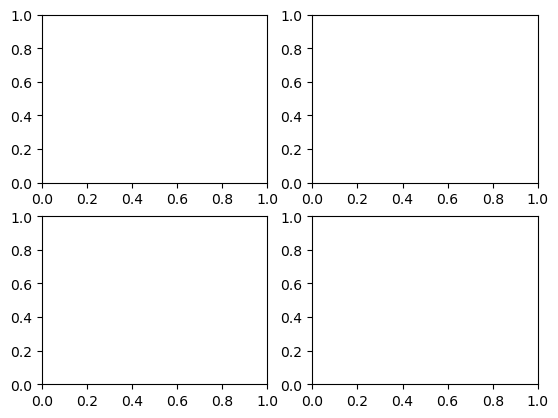

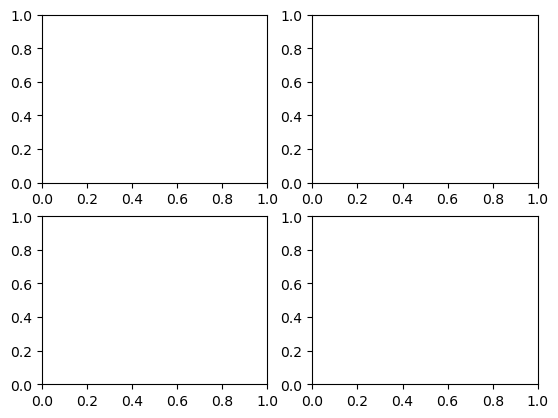

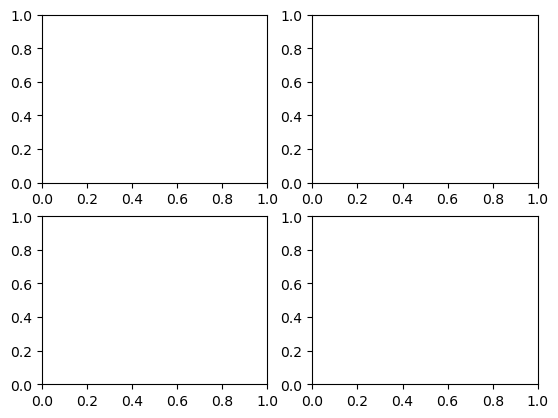

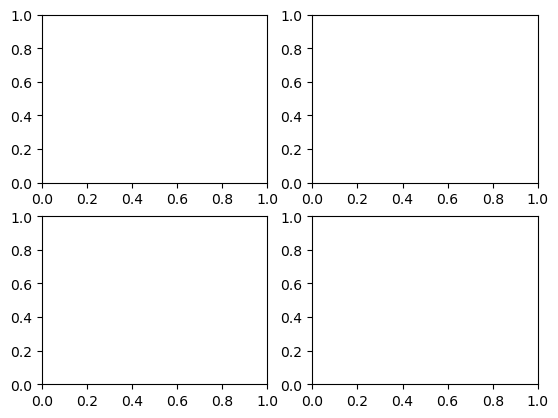

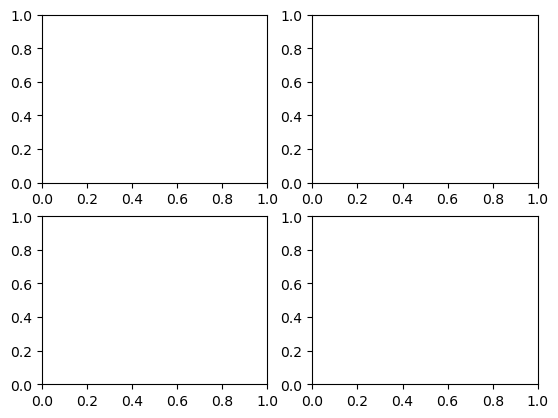

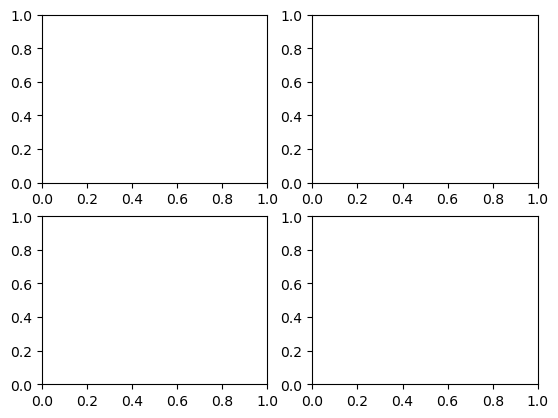

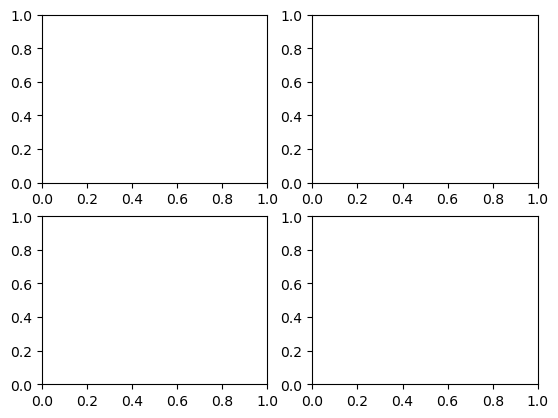

In [2]:
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper

DataImportWrapper().clean_all()

Overview generation of Datasets in experiment

In [3]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.parquet')
overview_df

Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

,Species,No. of footprints,No. of known individuals,No. of trails,No. of measurements
0,Amur Tiger (Panthera tigris altaica),605,44,86,128
1,Bengal Tiger (Panthera tigris tigris),586,40,87,128
2,Cheetah (Acinonyx jubatus),781,38,110,135
3,Eurasian Otter (Lutra lutra),628,42,80,205
4,Giant Panda (Ailuropoda melanoleuca),523,42,77,122
5,Lowland Tapir (Tapirus terrestris),426,37,64,90
6,Mountain Lion (Puma concolor),535,35,78,131
7,White Rhinoceros (Ceratotherium simum),1273,41,154,104


Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset. Train test splits needs to be executed here as it includes data cleaning steps that otherwise cause errors in the data exploration and visualisations functions that technically come beforehand in the dissertations


Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Splitting datasets:   0%|          | 0/8 [00:00<?, ?it/s]

✔️ Fold-Spalte in amur_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     99
1     93
2    100
3    102
4     81

📊 amur_tiger – train – 475 Zeilen | 35 Individuen | 68 Trails
sex
f    271
m    204

📊 amur_tiger – test – 130 Zeilen | 9 Individuen | 19 Trails
sex
f    73
m    57

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (parquet)
✔️ Fold-Spalte in bengal_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     91
1     73
2     91
3     53
4    128

📊 bengal_tiger – train – 436 Zeilen | 27 Individuen | 63 Trails
sex
m    262
f    174

📊 bengal_tiger – test – 112 Zeilen | 7 Individuen | 17 Trails
sex
m    66
f    46

📊 bengal_tiger – inference – 38 Zeilen | 6 Individuen | 7 Trails
sex
unknown    38

✅ bengal_tiger gespeichert (parquet)
✔️ Fold-Spalte in cheetah schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:244: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:244: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



✅ Fold method used: stratified_group
📊 Fold-Verteilung:
Fold
0    93
1    63
2    77
3    58
4    74
Name: count, dtype: int64
✔️ Fold-Spalte in eurasian_otter schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    93
1    63
2    77
3    58
4    74

📊 eurasian_otter – train – 365 Zeilen | 27 Individuen | 48 Trails
sex
f    204
m    161

📊 eurasian_otter – test – 182 Zeilen | 14 Individuen | 25 Trails
sex
f    102
m     80

📊 eurasian_otter – inference – 81 Zeilen | 1 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (parquet)
✔️ Fold-Spalte in giant_panda schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    108
1     71
2     98
3     71
4    105

📊 giant_panda – train – 453 Zeilen | 33 Individuen | 66 Trails
sex
f    273
m    180

📊 giant_panda – test – 70 Zeilen | 9 Individuen | 11 Trails
sex
m    42
f    28

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_pa

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Splits:   0%|          | 0/3 [00:00<?, ?it/s]


[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (81, 214)
[DEBUG] ds_label = eurasian_otter Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['lutra_lutra']
[DEBUG] species_code = lutra lutra
[DEBUG] sex value counts:
sex
Unknown    81
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Male, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Unknown, subset shape = (81, 214)
[DEBUG]  n_fp=81, n_ind=1, n_tr=8
[DEBUG]   fp_per_ind summary: mean=81.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=8.0, sd=0.0
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summary called for eurasian_otter/test, df shape = (182, 214)
[DEBUG] ds_label = eurasian_otter Test
[DEBUG] specie

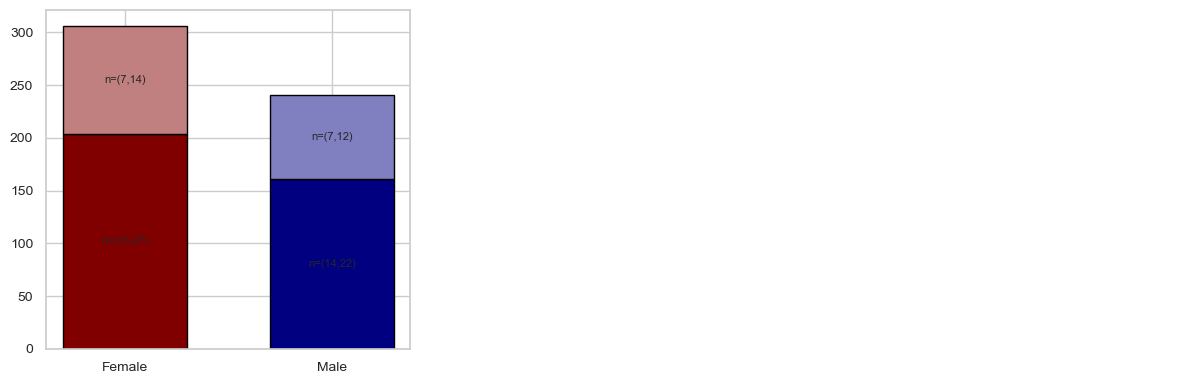

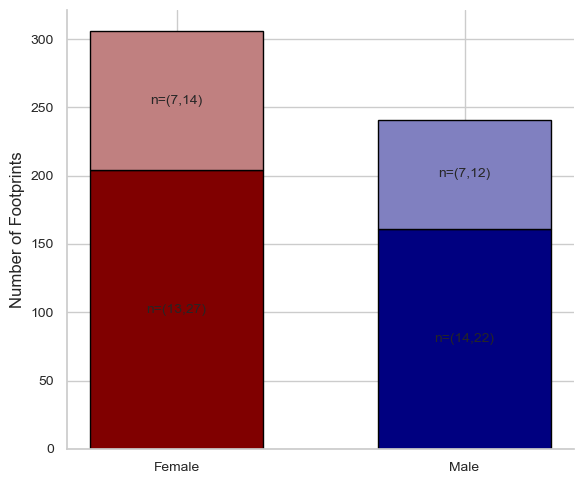

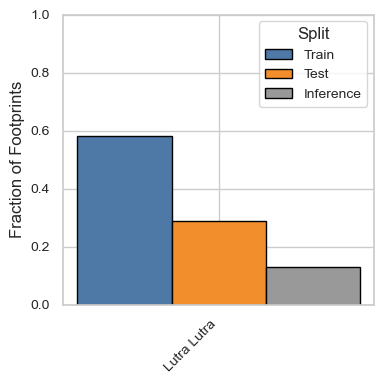

In [4]:
from FIT_python import config
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper

species = "eurasian_otter"
SplitWrapper().split_all(reuse_splits=True)

run_summary(config.SPLITS_DIR / species, species)


Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [5]:
from FIT_python.utils.paths import get_species_paths
from FIT_python.Visualisations.plots_utils import plot_feature_correlation_matrix, plot_individual_boxplots_2x1
from FIT_python import config as cfg
import pandas as pd
from FIT_python import config as cfg
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols


otter_df = pd.read_parquet(cfg.CLEANED_DIR / "Eurasian_Otter.parquet")


species = "eurasian_otter"

# get paths managed by the config (e.g. in dataprocessing/eurasian_otter/figures)
paths = get_species_paths(species, section="dataprocessing")
fig_dir = paths["figures"]          # directory already created by get_species_paths
fig_path = plot_feature_correlation_matrix(otter_df, fig_dir)  # figure saved here

feature_cols = get_feature_cols(otter_df)
# --- Aufruf ---
plot_individual_boxplots_2x1(
    df=otter_df,
    fig_dir=fig_dir,
    filename="individual_boxplots_2x1.png",
    feature_cols=feature_cols
)


[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[CAPTION] Boxplots of ['dist10_14', 't2_3_5'] grouped by individual


(WindowsPath('c:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/notebooks/results/fit_notebook_fast_7/results/dataprocessing/eurasian_otter/figures/individual_boxplots_2x1.png'),
 ['dist10_14', 't2_3_5'])

Visualisierung mit Umap alle Otter

c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Frede\AppData\Local\Temp\ipykernel_12360\2047129623.py:68: UserWarning: You passed a edgecolor/edgecolors ('black') for an u

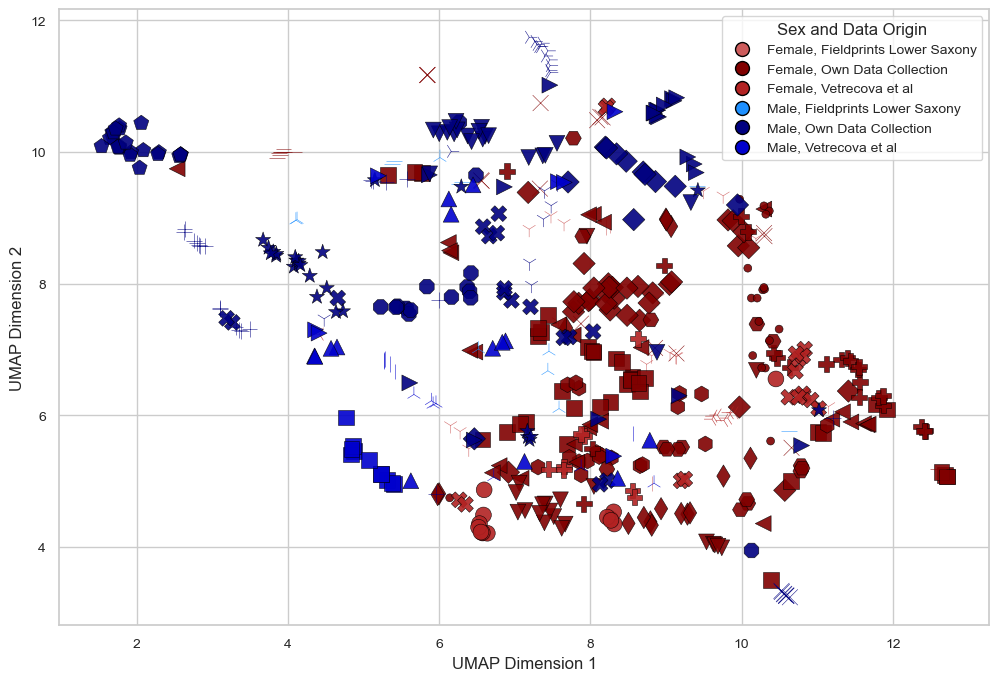

In [6]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.utils.paths import get_species_paths


# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]
species = "eurasian_otter"

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed
dr = DimensionalityReducerTransformer(
    method='umap',
    supervised=True,
    random_state=42    # Seed für Reproduzierbarkeit
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)
# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Kräftigere Farbpaletten für Sex mit klareren Schattierungen
sex_palette = {
    'Female': ["#800000", "#B22222", "#CD5C5C"],   # Dunkelrot → Rot → Hellrot
    'Male': ["#000080", "#0000CD", "#1E90FF"]      # Navy → Mittelblau → Hellblau
}
origin_order = ['Own Data Collection', 'Vetrecova et al', 'Fieldprints Lower Saxony']

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    palette = sex_palette[row['sex_mapped']]
    idx = origin_order.index(row['dataorigin']) % len(palette)
    return palette[idx]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,          # Noch größere Marker
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

# Legende nur mit Kreisen
from matplotlib.lines import Line2D
legend_elements = []
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    legend_elements.append(Line2D(
        [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
        markerfacecolor=group['color'].iloc[0], markersize=10, markeredgecolor='black'
    ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=10)


species = "eurasian_otter"
fig_dir = get_species_paths(species, section="dataprocessing")["figures"]
fig_path = fig_dir / "umap_individuals_sex_origin_bigmarkers_simplelegend.png"
plt.savefig(fig_path, dpi=300)
plt.show()


Training sex Model

In [7]:
from FIT_python.pipeline_sex.search import (
    run_otter_search_sex,
    run_other_species_search,
)
from FIT_python.pipeline_sex import collect_best_metrics
import FIT_python.config as cfg

# Hyper‑parameter search (reuses previous CSVs/models if present)
run_otter_search_sex(reuse_results=False)      # Eurasian otter
run_other_species_search()                    # all remaining species

# Summarise the best models across species
summary_df = collect_best_metrics(cfg.PATHS["sex_modelling"])
summary_df.head()

eurasian_otter BS-CV:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

KeyError: 'mean_test_accuracy'

Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6
Base data dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\results\sex_modelling
Benchmark dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\benchmark
⚠️ Fehlen CSV-Dateien in figures, überspringe.
⚠️ Fehlen CSV-Dateien in tables, überspringe.
✅ Benchmark-Tabelle gespeichert unter: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\benchmark\benchmark_summary_best_test.csv


,Species,Balanced Accuracy (Test),Accuracy (Test),Majority Vote Individual Accuracy (Test),Female Accuracy (Test),Male Accuracy (Test),Accuracy (CV),Balanced Accuracy (CV),Log Loss (CV)
0,Amur Tiger,0.993,0.992,1.000,0.971,1.000,0.898,0.908,-1.301
6,Mountain Lion,0.982,0.979,1.000,0.917,1.000,0.864,0.867,-0.296
1,Bengal Tiger,0.974,0.973,1.000,0.981,0.977,0.768,0.819,-0.646
3,Eurasian Otter,0.846,0.841,0.857,0.800,0.867,0.747,0.736,-0.565
2,Cheetah,0.693,0.694,0.875,0.707,0.677,0.473,0.489,-1.423
5,Lowlandtapir,0.636,0.629,0.500,0.703,0.492,0.524,0.560,-1.483
4,Giant Panda,0.631,0.571,0.667,0.950,0.364,0.758,0.718,-1.660
7,White Rhino,0.574,0.565,0.667,0.483,0.680,0.516,0.519,-3.824


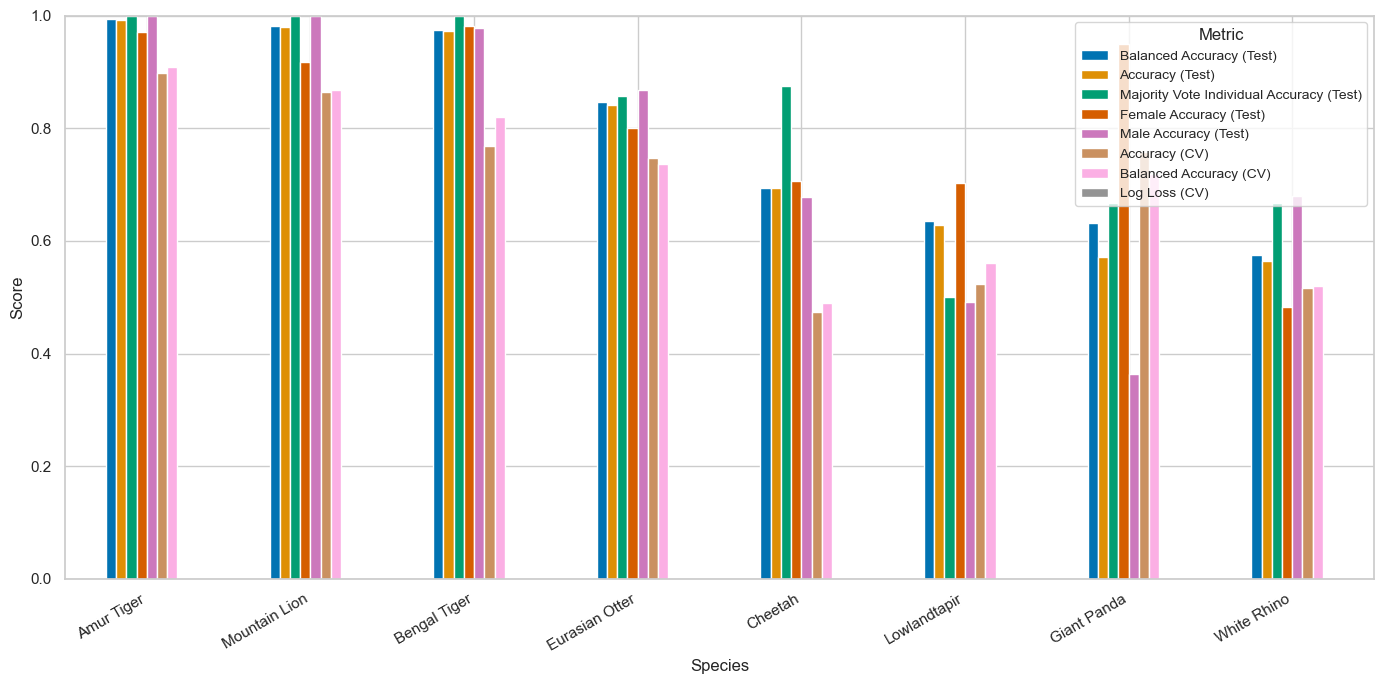

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib
from FIT_python.pipeline_sex.sex_predict_and_visualisation import predict_all
# ---------------------------------------------------------------------
# Projekt-Setup
# ---------------------------------------------------------------------
from FIT_python import config
importlib.reload(config)

# Basisverzeichnisse aus der config laden
base_dir = config.PATHS["sex_modelling"]
benchmark_dir = config.EXPERIMENT_ROOT / "benchmark"
benchmark_dir.mkdir(parents=True, exist_ok=True)

print("Experiment root:", config.EXPERIMENT_ROOT)
print("Base data dir:", base_dir)
print("Benchmark dir:", benchmark_dir)

# ---------------------------------------------------------------------
# Ergebnisse einsammeln
# ---------------------------------------------------------------------
sex_preds = predict_all(species, reuse_csv=False)
benchmark_rows = []
for species_dir in base_dir.iterdir():
    if not species_dir.is_dir():
        continue
    best_csv = species_dir / "tables" / "best_models.csv"
    all_csv  = species_dir / "tables" / "all_results.csv"

    if not (best_csv.exists() and all_csv.exists()):
        print(f"⚠️ Fehlen CSV-Dateien in {species_dir.name}, überspringe.")
        continue

    df_all = pd.read_csv(all_csv)
    if "balanced_test_acc" not in df_all.columns:
        print(f"⚠️ Keine Balanced Accuracy (Test) für {species_dir.name}, überspringe.")
        continue

    best_row = (
        df_all.sort_values("balanced_test_acc", ascending=False)
              .iloc[0]
              .to_dict()
    )
    best_row["species"] = species_dir.name
    benchmark_rows.append(best_row)

benchmark_df = pd.DataFrame(benchmark_rows)
if benchmark_df.empty:
    raise RuntimeError(
        f"Keine validen Ergebnisse in {base_dir} gefunden. "
        "Struktur: species/*(best_models.csv, all_results.csv)"
    )

# ---------------------------------------------------------------------
# Spalten sauber benennen (Test und CV getrennt)
# ---------------------------------------------------------------------
col_map = {
    "species": "Species",
    "balanced_test_acc": "Balanced Accuracy (Test)",
    "accuracy_test": "Accuracy (Test)",
    "maj_test_pct": "Majority Vote Individual Accuracy (Test)",
    "female_test_acc": "Female Accuracy (Test)",
    "male_test_acc": "Male Accuracy (Test)",
    "mean_test_accuracy": "Accuracy (CV)",
    "mean_test_balanced_accuracy": "Balanced Accuracy (CV)",
    "mean_test_neg_log_loss": "Log Loss (CV)",
}

cols_to_keep = [c for c in col_map if c in benchmark_df.columns]
benchmark_df = benchmark_df[cols_to_keep].rename(columns=col_map)

benchmark_df["Species"] = (
    benchmark_df["Species"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

sort_col = (
    "Balanced Accuracy (Test)"
    if "Balanced Accuracy (Test)" in benchmark_df.columns
    else benchmark_df.columns[1]
)

benchmark_df = benchmark_df.round(3).sort_values(sort_col, ascending=False)

# ---------------------------------------------------------------------
# Speichern
# ---------------------------------------------------------------------
out_path = benchmark_dir / "benchmark_summary_best_test.csv"
benchmark_df.to_csv(out_path, index=False)
print(f"✅ Benchmark-Tabelle gespeichert unter: {out_path}")
display(benchmark_df)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
sns.set_style("whitegrid")
metrics_for_plot = [c for c in benchmark_df.columns if c != "Species"]
palette = sns.color_palette("colorblind", n_colors=len(metrics_for_plot))

ax = benchmark_df.set_index("Species")[metrics_for_plot].plot(
    kind="bar", figsize=(14, 7), color=palette
)
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Species", fontsize=12)
ax.legend(title="Metric", fontsize=10)
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(benchmark_dir / "benchmark_summary_best_test_plot.png", dpi=300)
plt.show()


Verteilung nach Splits:
__split__
train        365
test         182
inference     81
Name: count, dtype: int64 



,id,species,individual_id,date,location,dataorigin,substrate,sex,trail,dist1_2,...,t12_13_15,t13_14_15,t13_14_17,t12_15_17,t13_14_16,Fold,__split__,pred_sex,pred_proba_f,pred_proba_m
0,1989,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.195434,...,45.614587,45.614587,22.519170,21.979226,16.757686,1.0,train,f,0.97,0.03
1,1990,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.078705,...,43.571373,43.571373,18.882423,19.962604,12.480125,1.0,train,f,0.79,0.21
2,1991,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.130907,...,40.660357,40.660357,19.281442,18.500245,13.776469,1.0,train,m,0.12,0.88
3,1992,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.211265,...,39.990505,39.990505,15.972883,15.033439,10.469460,1.0,train,m,0.00,1.00
4,1993,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,1.938635,...,46.219886,46.219886,22.458678,21.324311,16.092507,1.0,train,f,0.94,0.06


Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6
Sex plot directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots


C:\Users\Frede\AppData\Local\Temp\ipykernel_6600\975039069.py:51: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


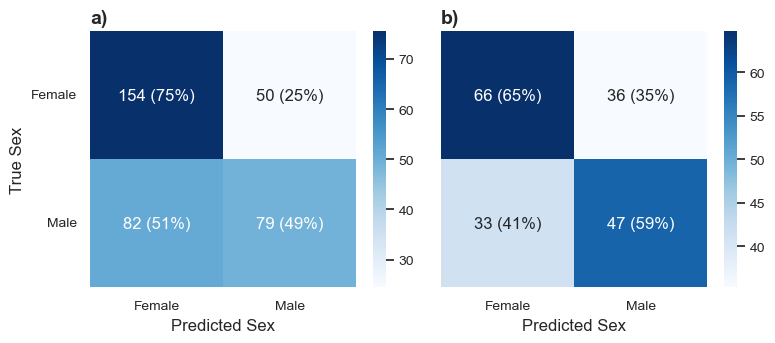

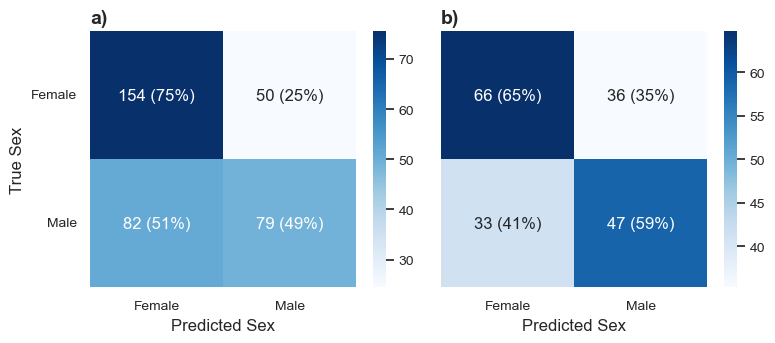

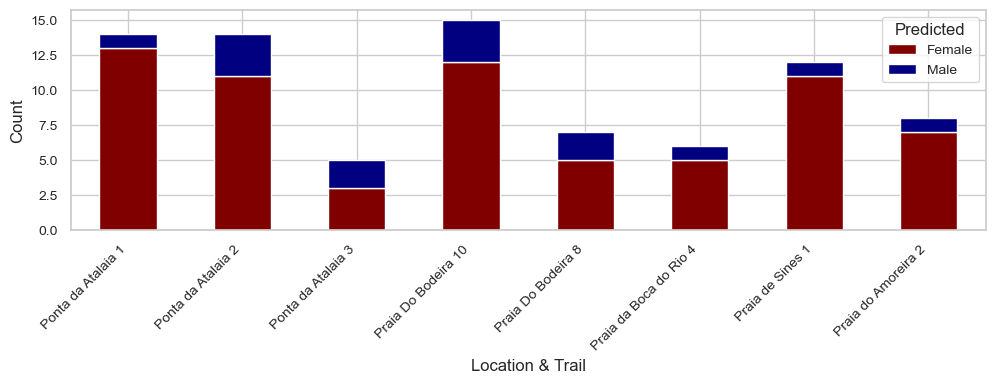

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

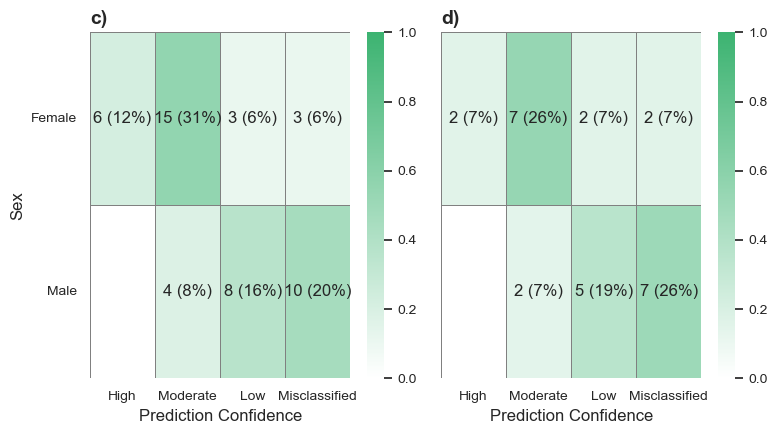

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

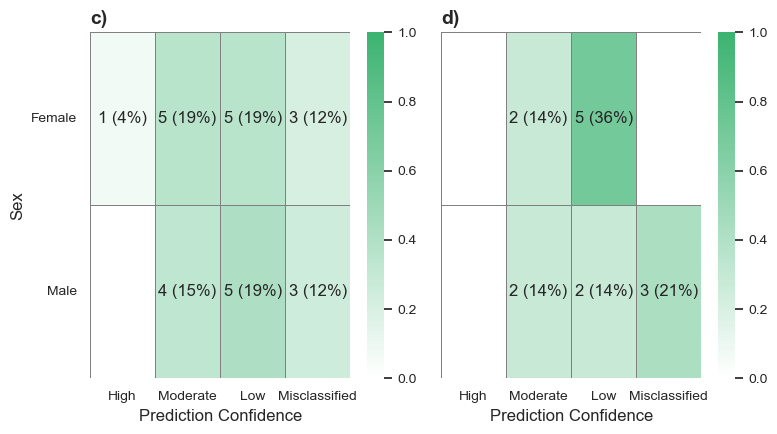

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


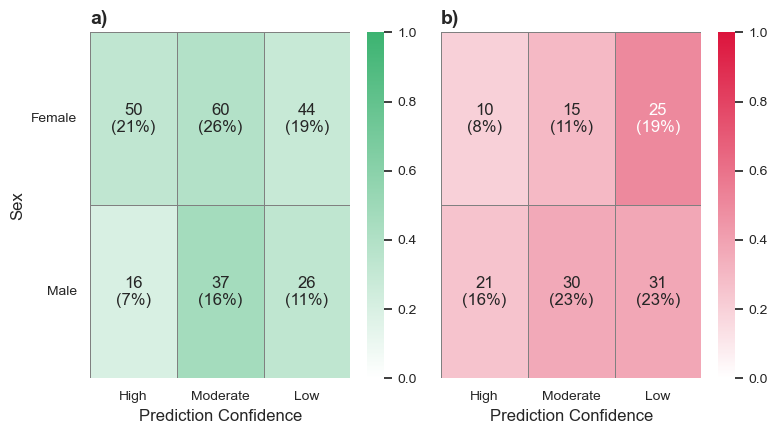

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


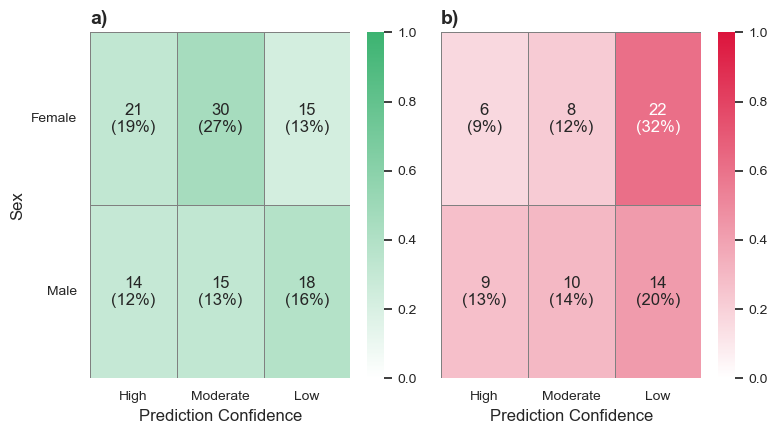

✅ Fertig. (Zusätzliche Dateien landen in: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots)


In [ ]:
# %% Imports
import importlib
from pathlib import Path
import pandas as pd
import numpy as np

from FIT_python import config
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all,
    plot_confusion,
    plot_confusion_and_inference,
    plot_quality_grouped,
    plot_quality_heatmaps,
    plot_hist_predsex_train_test,
    # plot_individual_probabilities,   # optional
)

# ---------------------------------------------------------------------
# Config laden / refresh (falls im Notebook geändert wurde)
# ---------------------------------------------------------------------
importlib.reload(config)

# === Konfiguration ===
DEFAULT_SPECIES = "eurasian_otter"
METRIC_KEY = "balanced_accuracy"

# ---------------------------------------------------------------------
# Predictions erzeugen (inkl. OOF für Train) – CSV wird im species-Pfad abgelegt
# ---------------------------------------------------------------------
df_all = predict_all(
    species=DEFAULT_SPECIES,
    metric_key=METRIC_KEY,
    prefer_generic=False,
    include_inference=True,
    reuse_csv=False,
    use_cv_train_predictions=True
)

# --- Verteilung Train / Test / Inference prüfen ---
print("Verteilung nach Splits:")
print(df_all["__split__"].value_counts(), "\n")

# --- Kopf zur Kontrolle ---
display(df_all.head())

# ---------------------------------------------------------------------
# Sex-Mapping (nur falls 'pred_sex' Zahlen statt 'f'/'m' enthält)
# ---------------------------------------------------------------------
if "pred_sex" in df_all.columns:
    sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}
    df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)

# ---------------------------------------------------------------------
# Ausgabeordner für zusätzliche Plots / Exporte
# ---------------------------------------------------------------------
sex_dir = config.EXPERIMENT_ROOT / "Sex_plots"
sex_dir.mkdir(parents=True, exist_ok=True)
print("Experiment root:", config.EXPERIMENT_ROOT)
print("Sex plot directory:", sex_dir)

# ---------------------------------------------------------------------
# Plots erzeugen
# ---------------------------------------------------------------------
plot_confusion(df_all)
plot_confusion_and_inference(df_all)
plot_quality_grouped(df_all)
plot_quality_heatmaps(df_all)
plot_hist_predsex_train_test(df_all)
# Optional mit Speicherung:
# plot_individual_probabilities(df_all, out_dir=sex_dir)

print(f"✅ Fertig. (Zusätzliche Dateien landen in: {sex_dir})")


Confusion matrix Train und testset

Baseline Model mit basis FIT parameter


📊 Running prediction & plots for metric: accuracy


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.822e-03, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.304e-03, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the fe

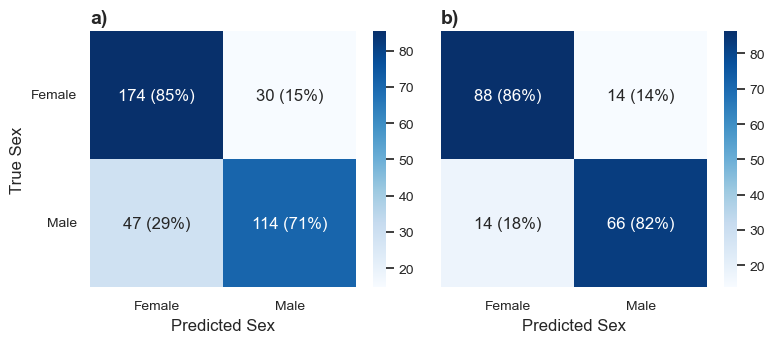

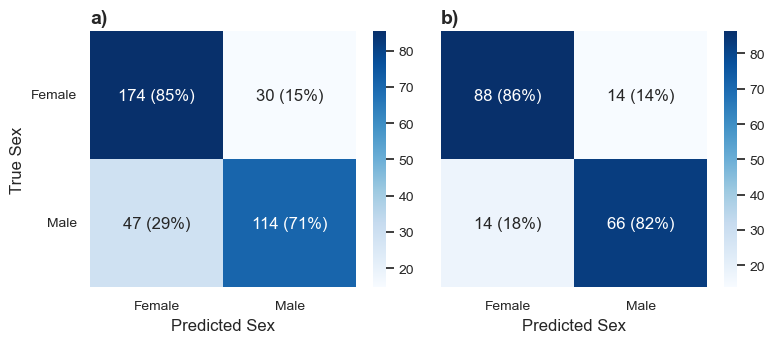

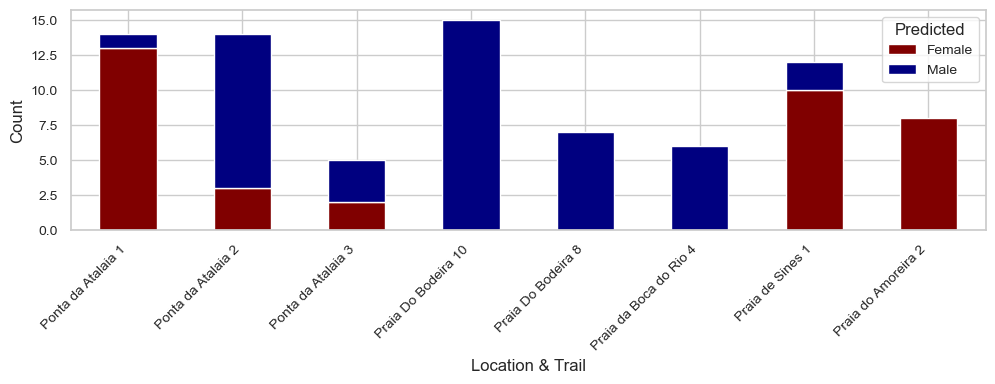

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

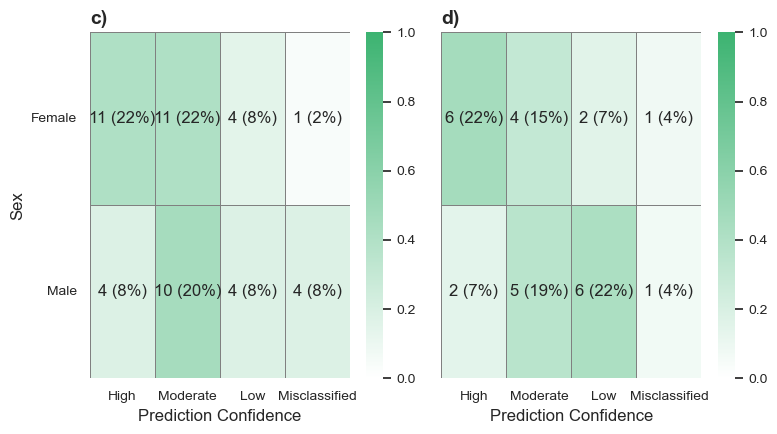

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

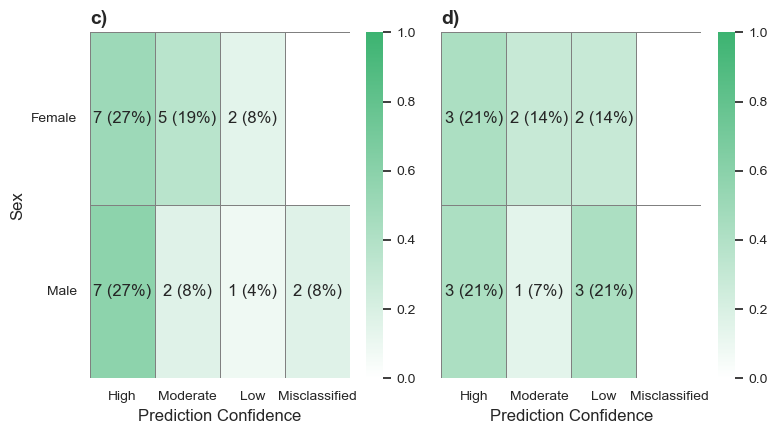

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


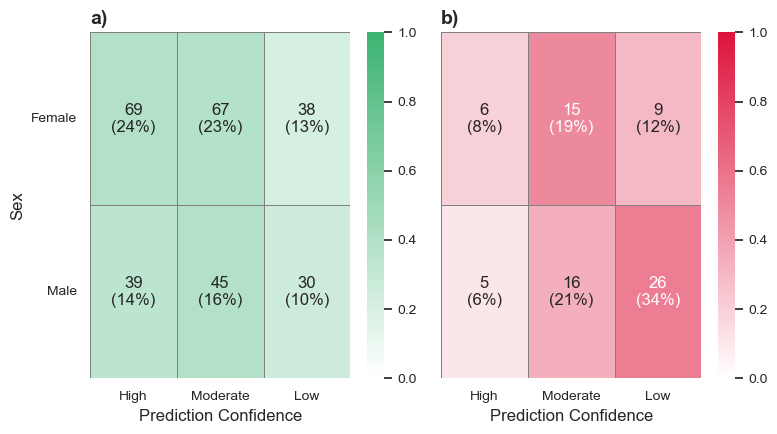

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


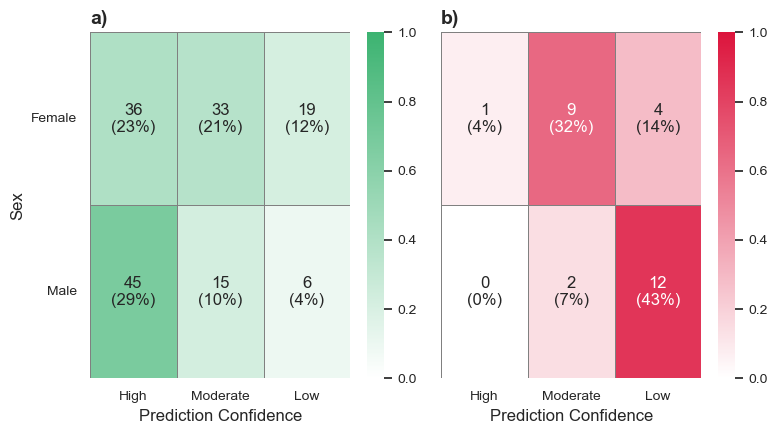

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für accuracy gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots\accuracy

📊 Running prediction & plots for metric: balanced_accuracy


C:\Users\Frede\AppData\Local\Temp\ipykernel_6600\1279085851.py:76: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


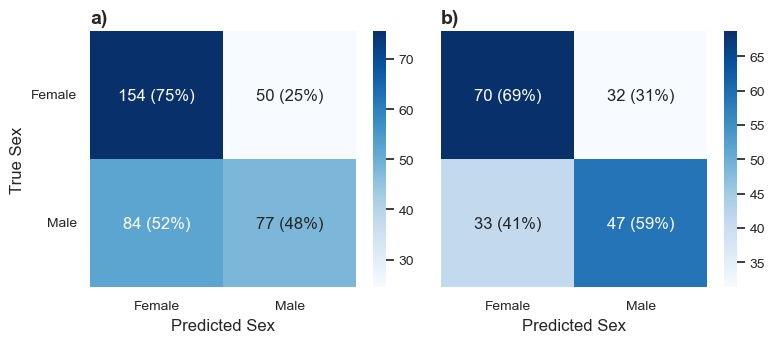

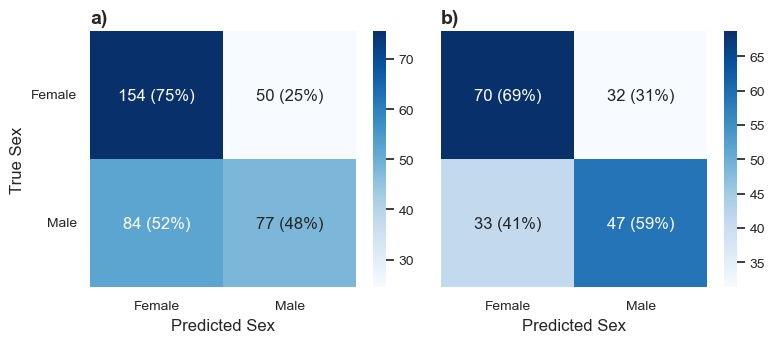

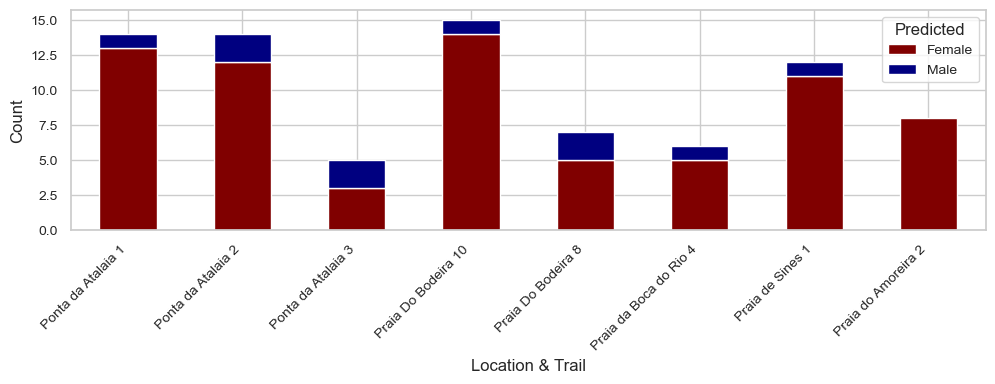

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

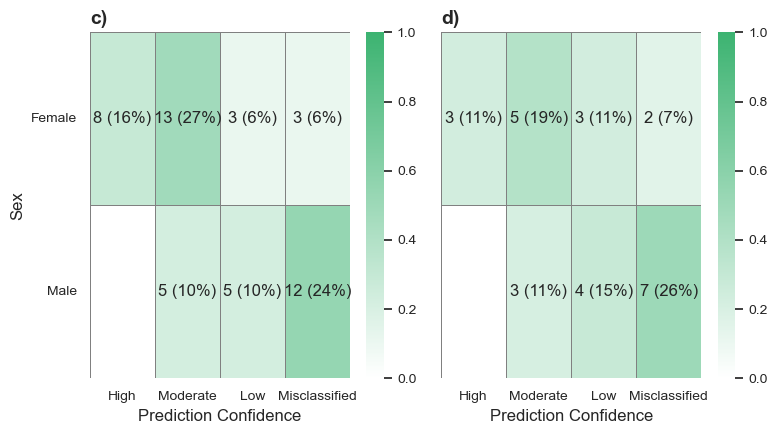

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

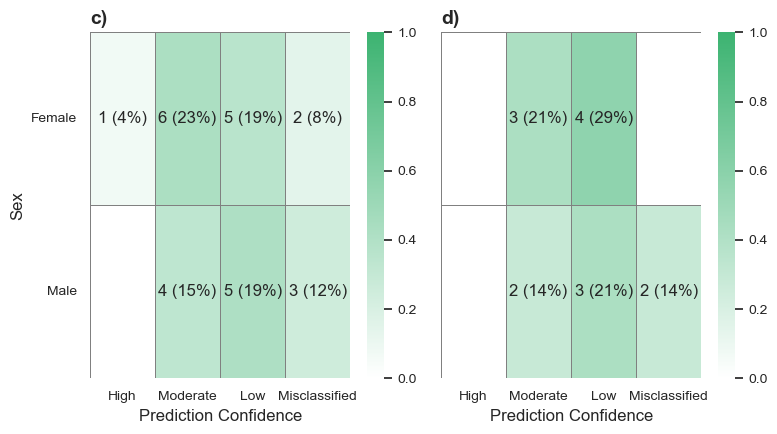

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


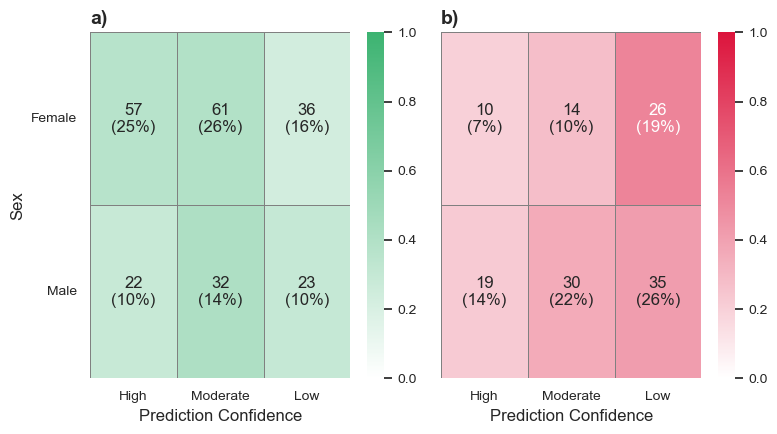

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


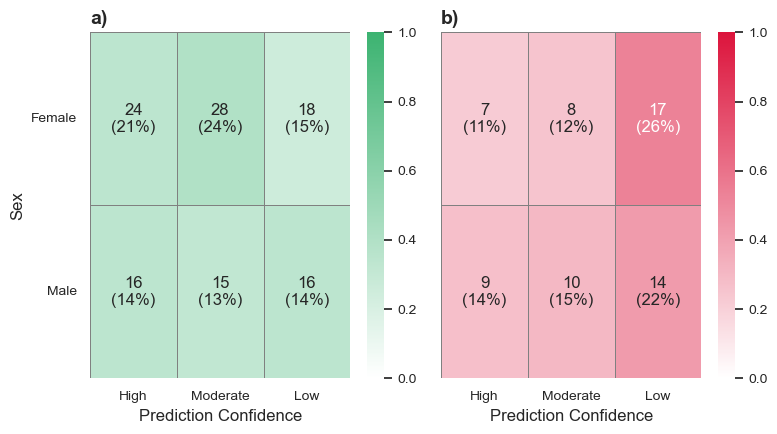

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für balanced_accuracy gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots\balanced_accuracy

📊 Running prediction & plots for metric: neg_log_loss


C:\Users\Frede\AppData\Local\Temp\ipykernel_6600\1279085851.py:76: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


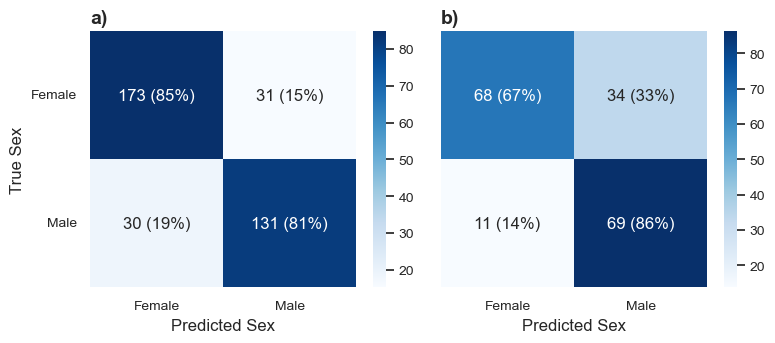

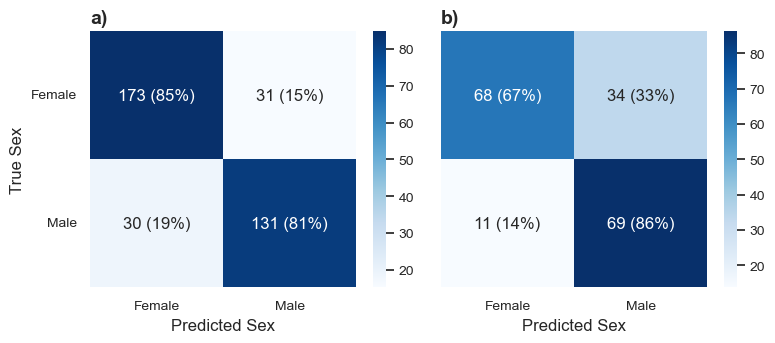

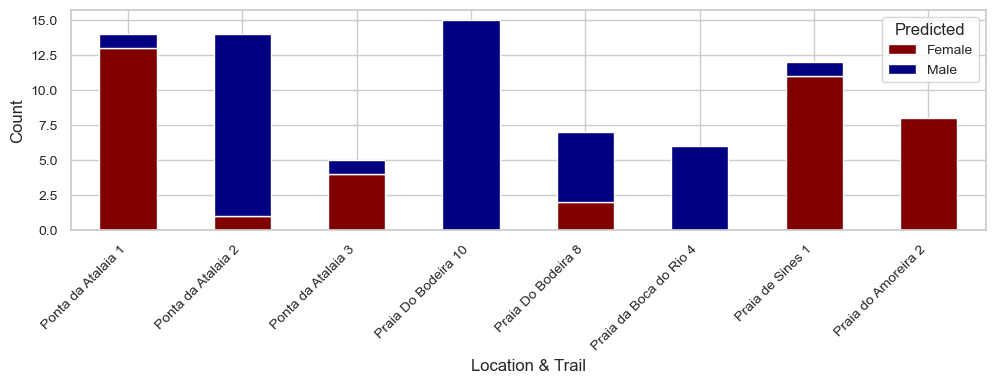

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

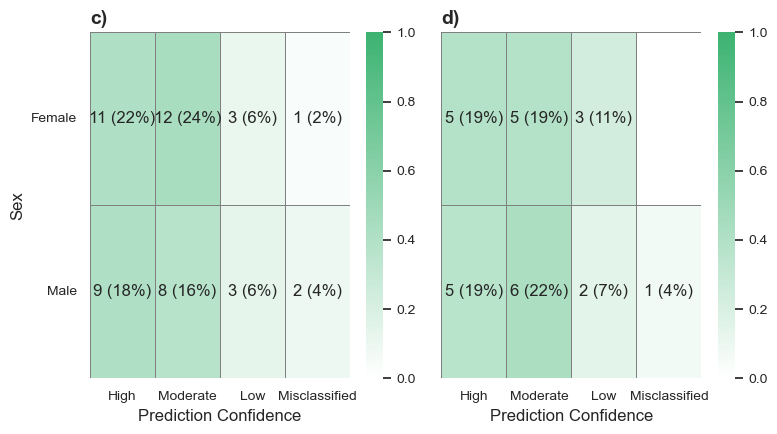

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

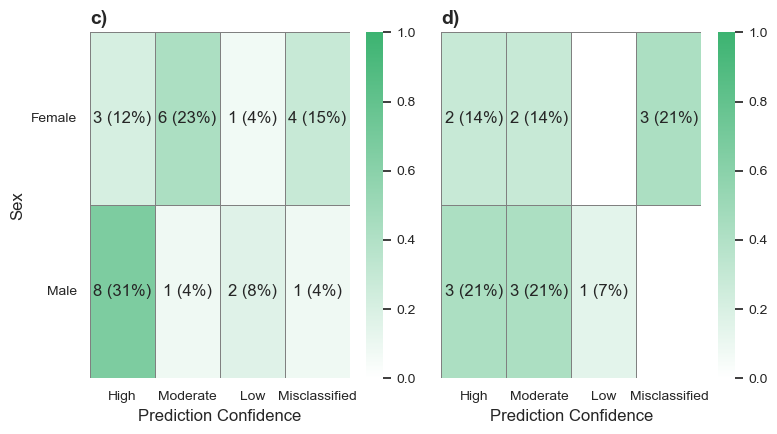

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


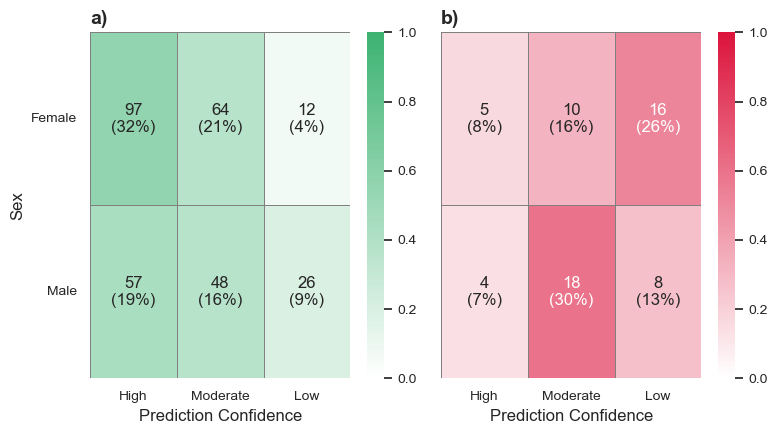

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


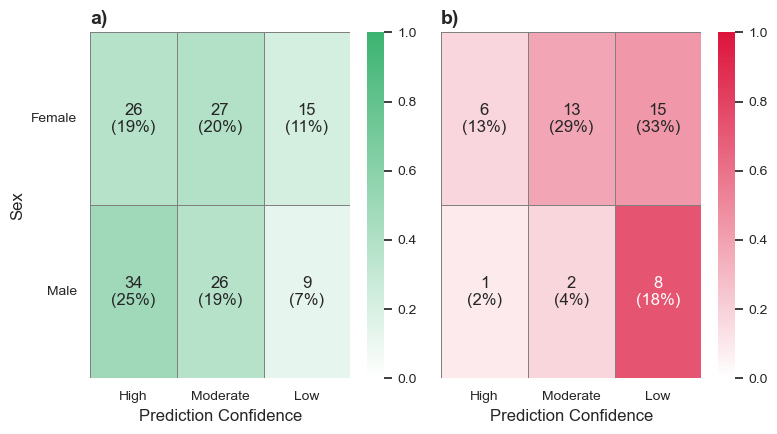

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für neg_log_loss gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots\neg_log_loss

📊 Running prediction & plots for metric: f1


C:\Users\Frede\AppData\Local\Temp\ipykernel_6600\1279085851.py:76: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


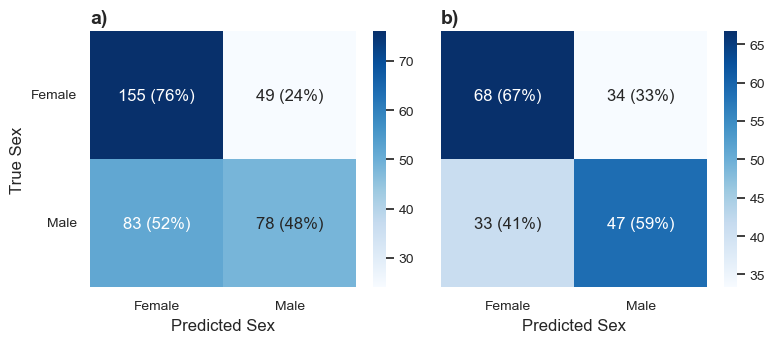

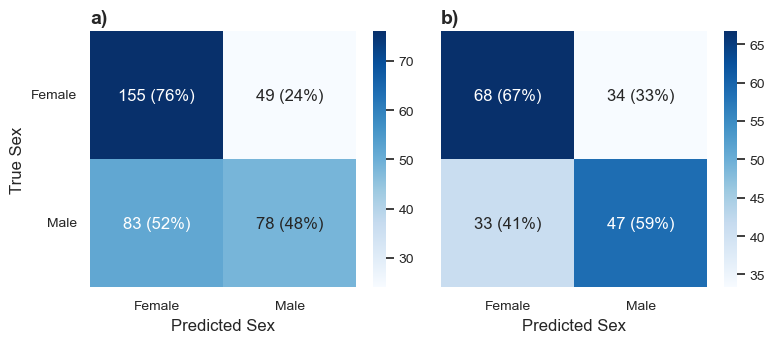

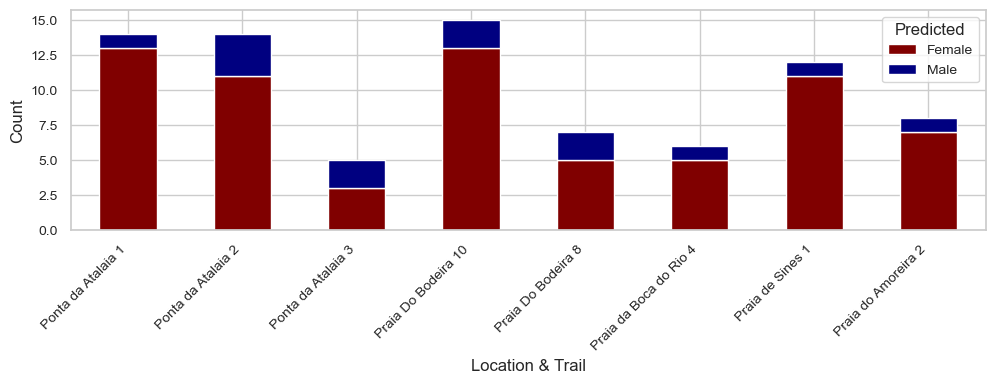

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

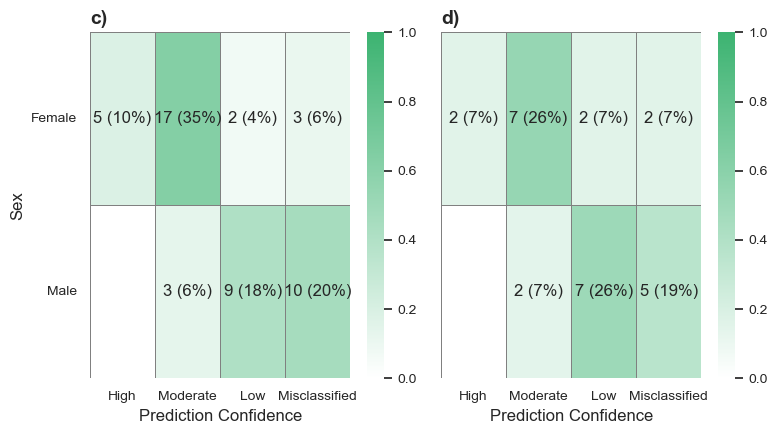

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

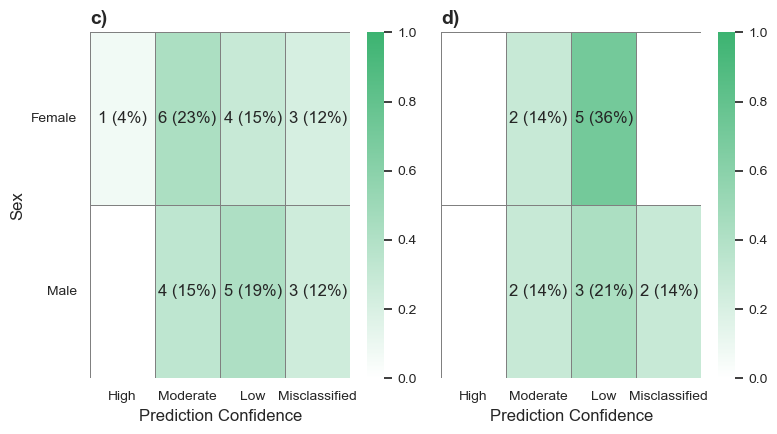

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


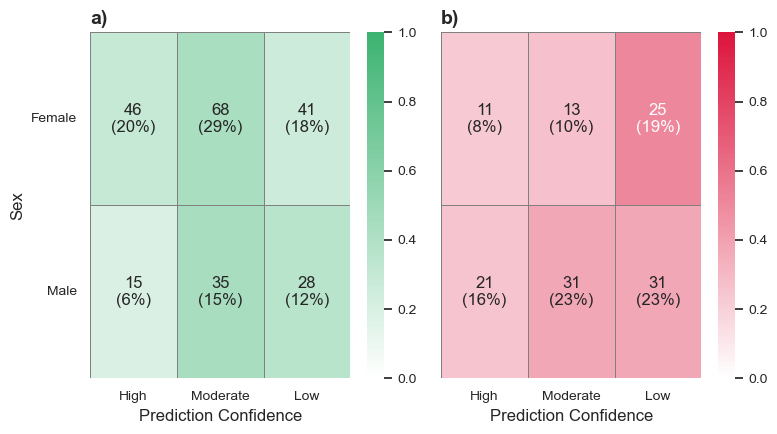

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


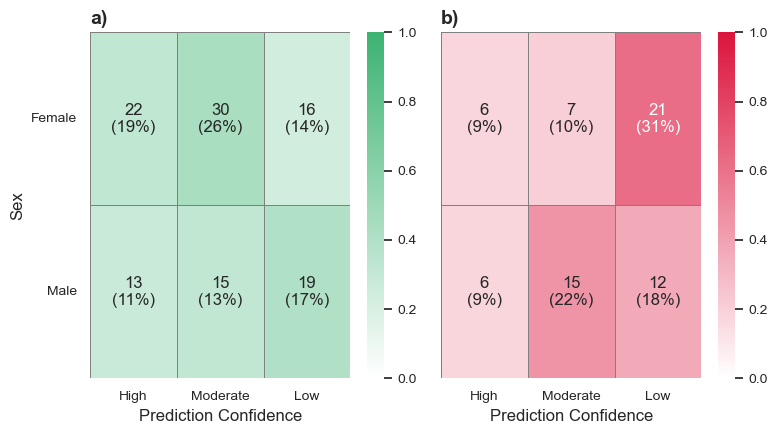

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für f1 gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots\f1

📊 Running prediction & plots for metric: precision


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.822e-03, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.304e-03, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the fe

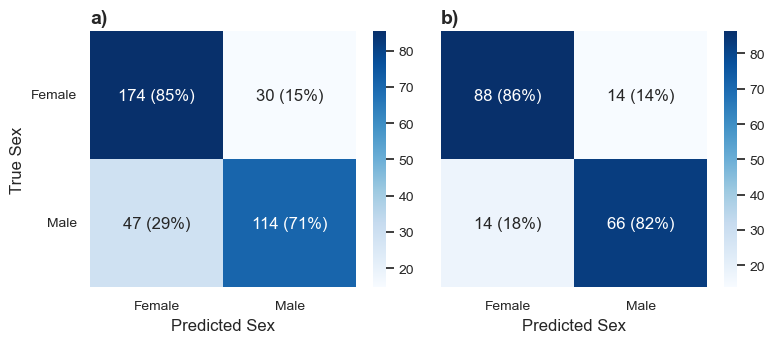

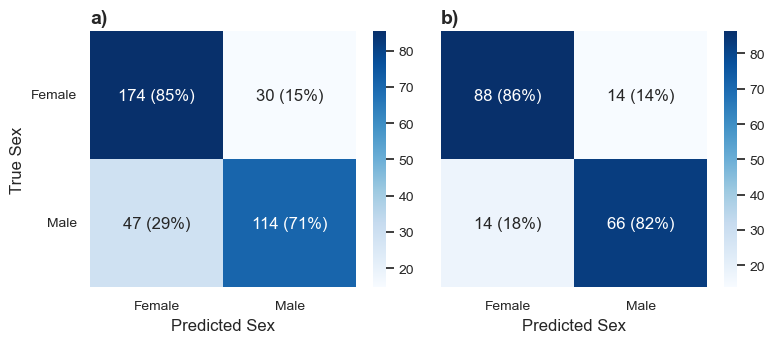

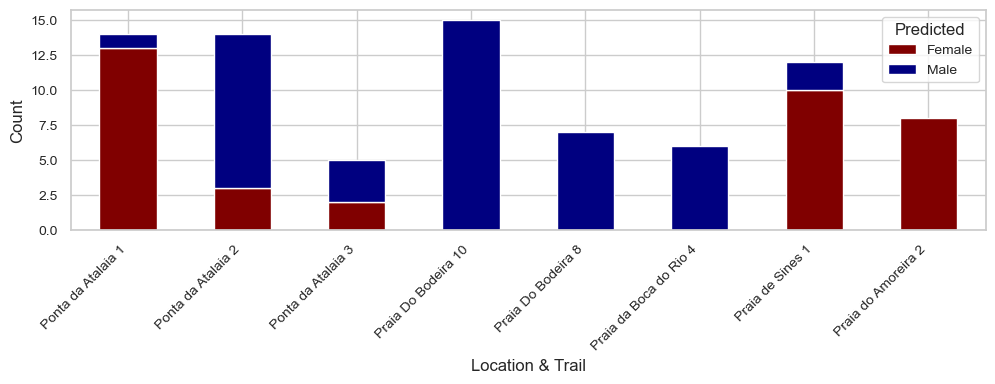

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

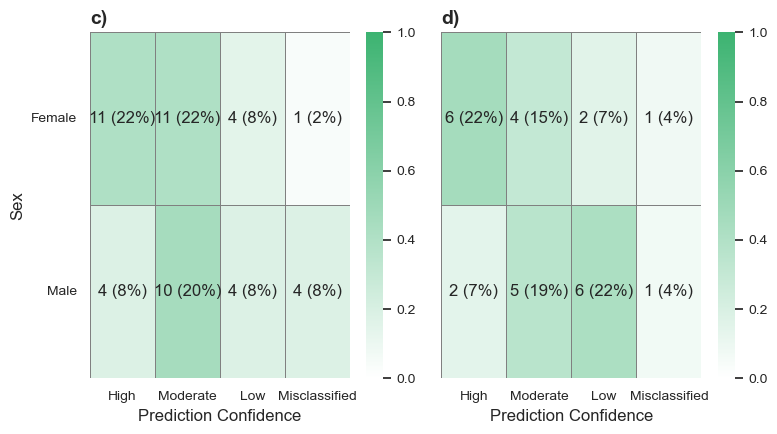

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

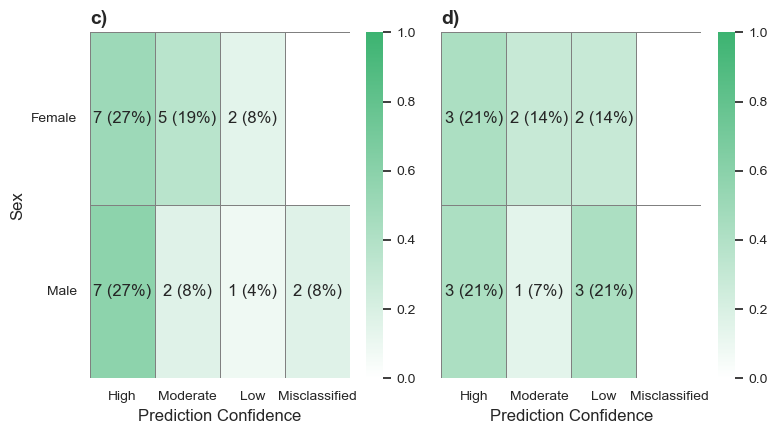

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


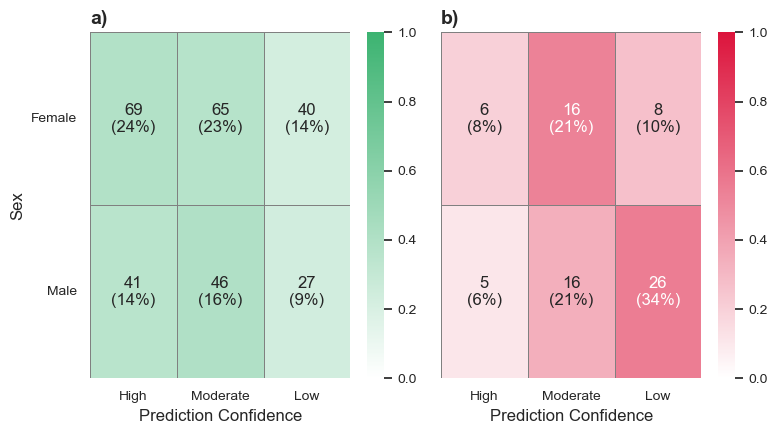

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


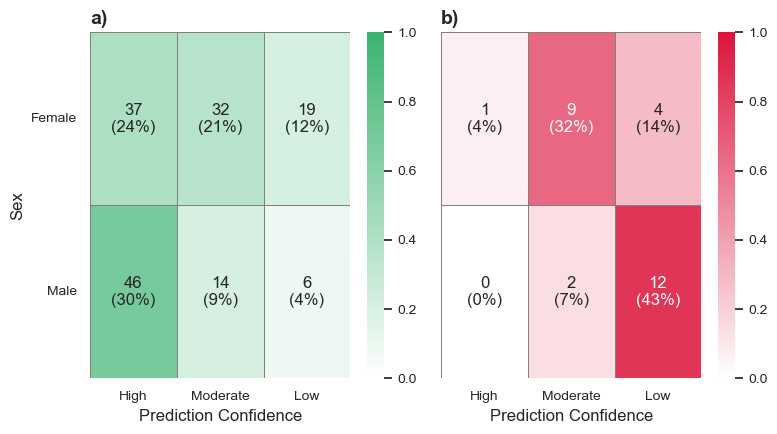

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für precision gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots\precision

📊 Running prediction & plots for metric: recall


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.790e-03, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.625e-02, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the fe

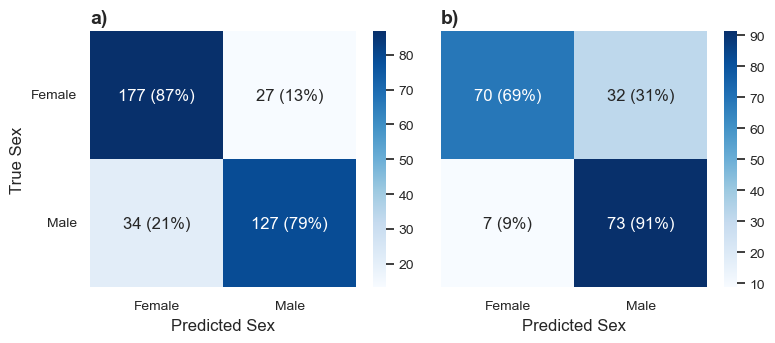

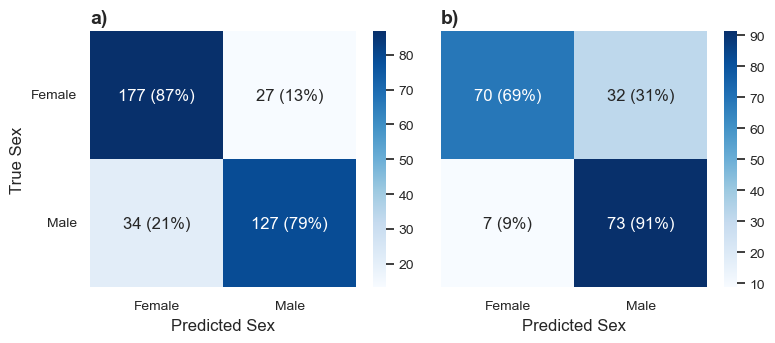

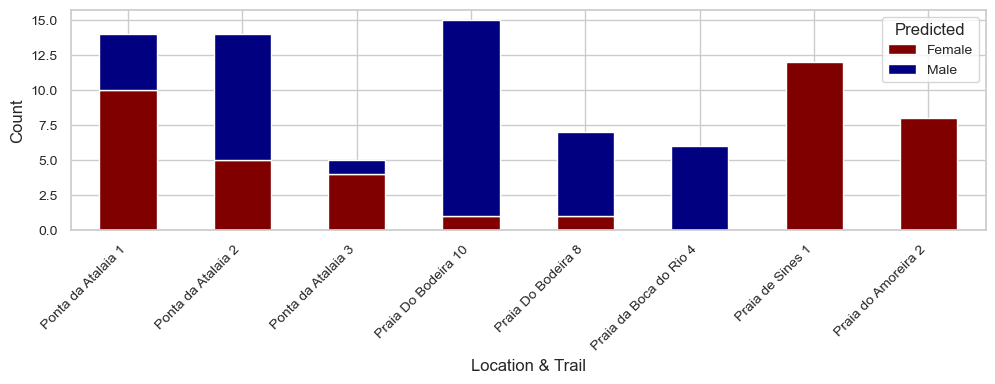

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

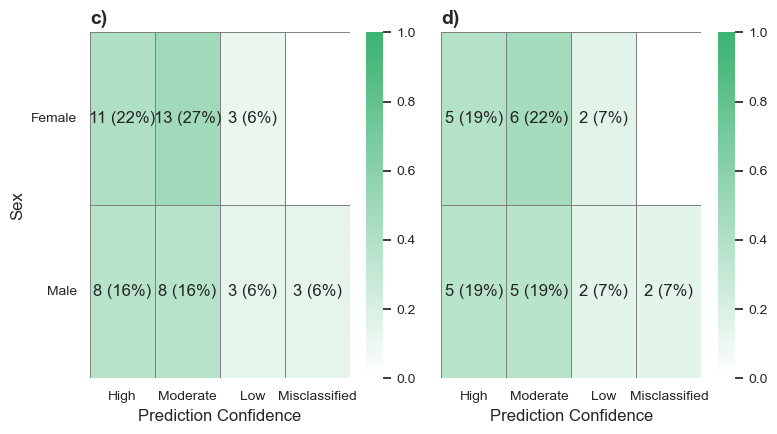

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

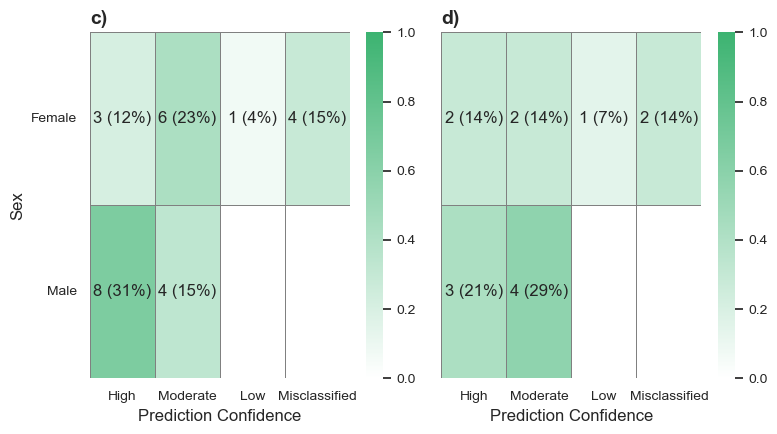

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


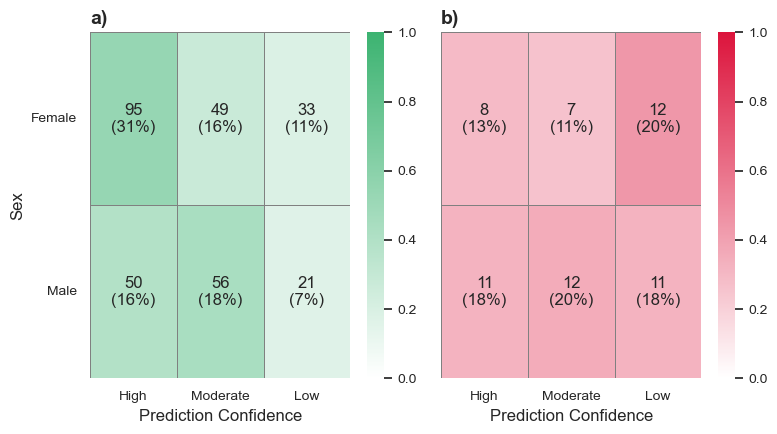

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


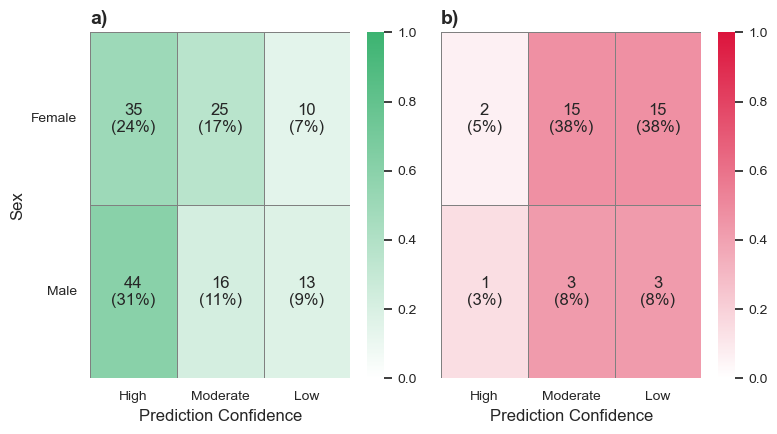

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für recall gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots\recall

📊 Running prediction & plots for metric: roc_auc


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.822e-03, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.304e-03, tolerance: 4.315e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the fe

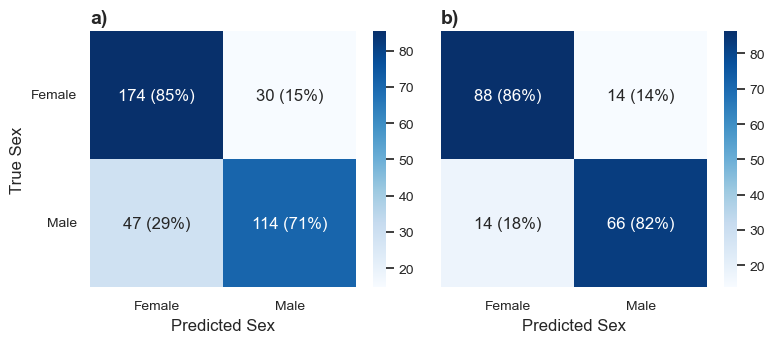

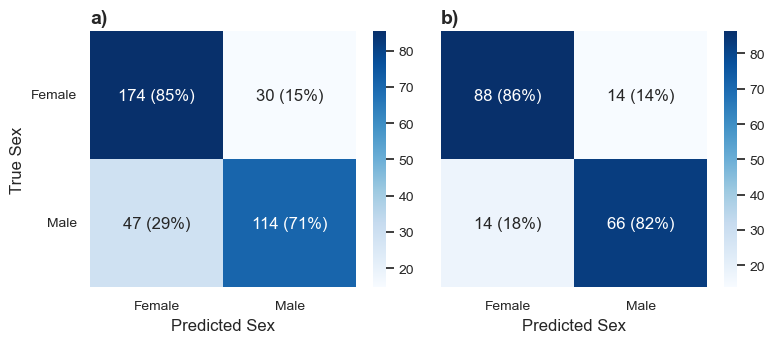

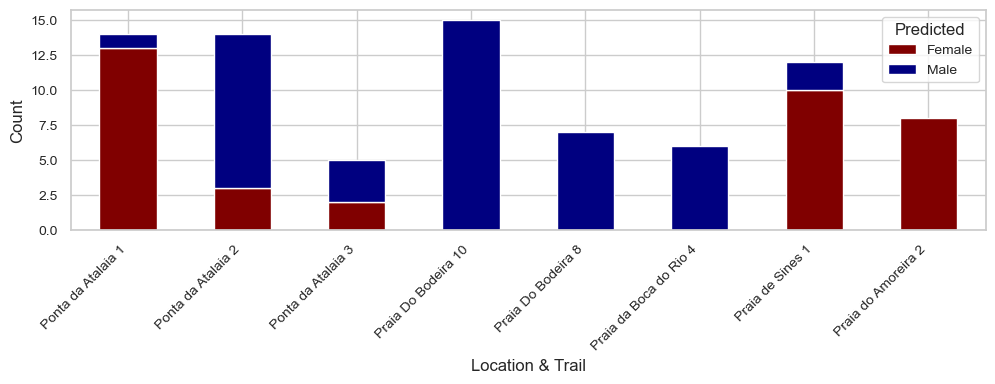

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

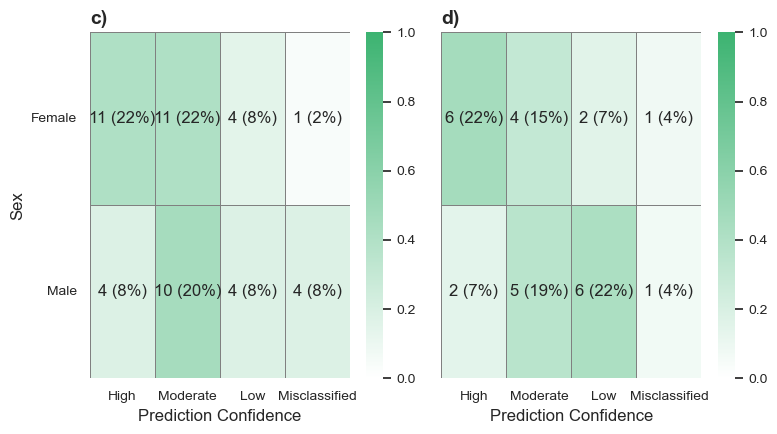

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

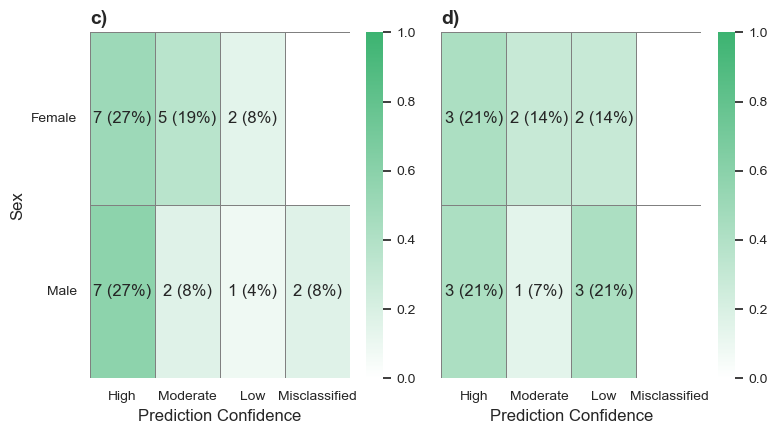

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


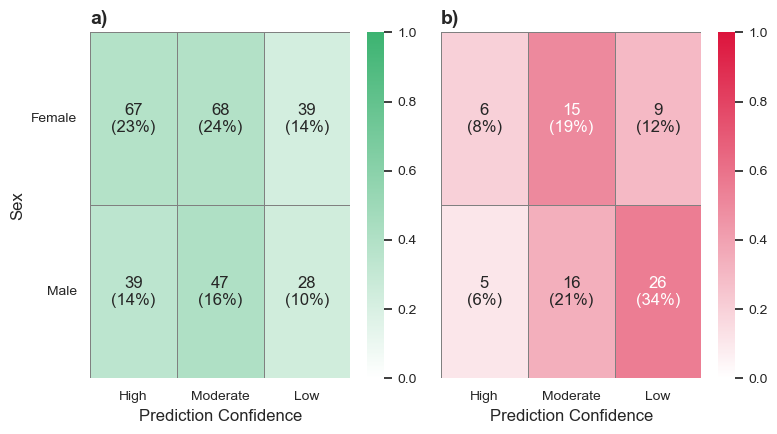

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


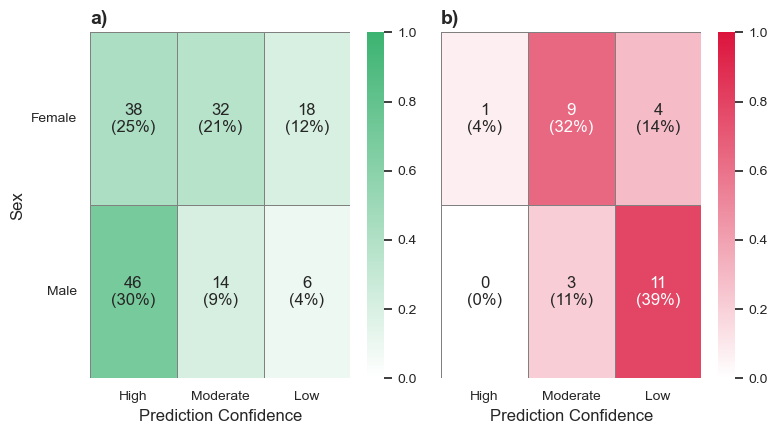

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für roc_auc gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\Sex_plots\roc_auc


In [ ]:
# === Imports ===
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import importlib

from FIT_python import config
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all,
    plot_confusion_and_inference,
    plot_quality_grouped,
    plot_quality_heatmaps,
    plot_individual_probabilities,
    plot_confusion,
    plot_hist_predsex_train_test,   # <- fehlte vorher
)

# === Config refresh ===
importlib.reload(config)

# === Parameter ===
DEFAULT_SPECIES = "eurasian_otter"
SCORING_METRICS = list(config.CONFIG["pipeline_sex"]["scoring"].keys())
BASE_DIR = config.EXPERIMENT_ROOT
SEX_DIR = BASE_DIR / "Sex_plots"
SEX_DIR.mkdir(parents=True, exist_ok=True)

sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}

# === Funktion für Histogrammplots ===
def plot_histogram_per_model(df, metric_key, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    df_plot = df.copy()
    df_plot["true_label"] = df_plot["sex"].replace(sex_mapping)
    df_plot["split_label"] = df_plot["__split__"].replace({"train": "Train (CV)", "test": "Test"})

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for i, split in enumerate(["train", "test"]):
        df_sub = df_plot[df_plot["__split__"] == split]
        if df_sub.empty:
            continue
        sns.histplot(
            data=df_sub,
            x="pred_sex",
            hue="individual_id",
            multiple="stack",
            bins=10,
            ax=axes[i],
            palette="Set2",
            legend=False
        )
        axes[i].set_title(f"{split.capitalize()} Set – Prediction Distribution")
        axes[i].set_ylabel("Count")
    axes[1].set_xlabel("Predicted Sex (0=F, 1=M)")
    fig.suptitle(f"Prediction Histogram by Individual – {metric_key}", fontsize=14)
    plt.tight_layout()
    fig.savefig(out_dir / f"prediction_histogram_{metric_key}.png", dpi=300)
    plt.close()

# === Hauptloop über alle Scoring-Metriken ===
for metric_key in SCORING_METRICS:
    print(f"\n📊 Running prediction & plots for metric: {metric_key}")
    df_all = predict_all(
        species=DEFAULT_SPECIES,
        metric_key=metric_key,
        prefer_generic=False,
        include_inference=True,
        reuse_csv=False,               # neu schreiben, damit immer konsistent
        use_cv_train_predictions=True
    )

    # Mapping für Vorhersage vereinheitlichen
    if "pred_sex" in df_all.columns:
        df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)

    out_dir = SEX_DIR / metric_key
    out_dir.mkdir(parents=True, exist_ok=True)

    # Plots
    plot_confusion(df_all)
    plot_confusion_and_inference(df_all)
    plot_quality_grouped(df_all)
    plot_quality_heatmaps(df_all)
    plot_individual_probabilities(df_all, out_dir=out_dir)
    plot_hist_predsex_train_test(df_all)

    # Histogramm zusätzlich
    plot_histogram_per_model(df_all, metric_key, out_dir)

    print(f"✅ Ergebnisse für {metric_key} gespeichert in {out_dir}")


In [ ]:
# === Imports ===
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
import time

from FIT_python.pipeline_individual_id.simple_baseline import (
    run_fold_cv,
    get_feature_cols,
)
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import (
    generate_pairwise_comparisons_from_df,
)
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_sex.sex_predict_and_visualisation import predict_all
from FIT_python.pipeline_sex.sex_model_loader import get_sex_model_path  # <-- NEU

# --- Config laden (soft-coded) ---
from FIT_python import config as cfg
importlib.reload(cfg)

# Pfade aus config
base_dir     = cfg.SPLITS_DIR                        # <EXPERIMENT_ROOT>/data/splits
out_base_dir = cfg.PATHS["individual_id"]            # <EXPERIMENT_ROOT>/results/individual_id
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# Mapping wissenschaftlich -> common aus config (soft-coded)
SPECIES_MODEL_MAP = {k.lower(): v for k, v in cfg.SPECIES_MODEL_MAP.items()}
def to_common_name(name: str) -> str:
    return SPECIES_MODEL_MAP.get((name or "").lower(), name)

# Laufparameter
results = {}
k_range = range(14, 18)
selection_methods = ["lasso", "random_forest", "forward"]
sex_flags = [True]  # ggf. [False, True]

# === Hauptschleife ===
for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue

    species_raw = sp_dir.name
    species     = to_common_name(species_raw)  # common name für Modelle/Ergebnisse
    print(f"\n##### {species_raw}  →  {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path  = sp_dir / "test.parquet"
    infer_path = sp_dir / "inference.parquet"

    if not train_path.exists() or not test_path.exists():
        print(f"⚠️  Überspringe {species_raw}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)

    include_inference = False
    if infer_path.exists():
        df_inf = pd.read_parquet(infer_path)
        include_inference = len(df_inf) > 0

    print(
        f"📊 Datensatzgrößen – "
        f"Train: {len(df_train)}, Test: {len(df_test)}, "
        f"Inference: {len(df_inf) if include_inference else 0}"
    )

    feature_cols = get_feature_cols(df_train)

    # Species-Output
    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    master_pairs = []

    # === Sex-Predictions (OOF für Train; Full-Train für Test/Inference)
    sex_preds = predict_all(
        species=species,                          # common name!
        metric_key=cfg.SEX_PREDICT_METRIC,        # z.B. "balanced_accuracy"
        prefer_generic=False,
        include_inference=include_inference,
        reuse_csv=False,                          # CSV bei Bedarf neu schreiben
        use_cv_train_predictions=True,
    )

    # >>> Kritisch: den korrekten Sex-Model-Pfad SOFT-CODED auflösen
    sex_model_fp = get_sex_model_path(species=species, metric=cfg.SEX_PREDICT_METRIC)
    # z.B.: <EXPERIMENT_ROOT>/results/sex_modelling/<common>/models/<metric>/<common>.joblib
    print("🔗 Sex model:", sex_model_fp)

    for fs in selection_methods:
        for k in k_range:
            for use_sex in sex_flags:
                start_time = time.perf_counter()
                tag = f"{fs}_k{k}_{'sex' if use_sex else 'morph'}"

                # 1) CV
                cv_dir = out_dir / tag / "cv_results"
                cv_dir.mkdir(parents=True, exist_ok=True)

                # k in zentraler CONFIG spiegeln (optional)
                cfg.CONFIG["pipeline_individual_id"]["pairwise_defaults"]["k_features"] = k

                summary_cv = run_fold_cv(
                    df_train,
                    feature_cols,
                    sex_predictions=sex_preds,
                    fold_col="Fold",
                    out_dir=cv_dir,
                    selection_method=fs,
                    k_features=k,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    reuse_summary=True,
                    sexmodel_path=sex_model_fp,          # <-- WICHTIG: Pfad explizit übergeben
                )
                print(f"CV fertig: {species} – {tag}")

                # CV-Paare laden/annotieren
                cv_pairs_fp = cv_dir / "all_folds.csv"
                if cv_pairs_fp.exists():
                    cv_pairs = pd.read_csv(cv_pairs_fp)
                    cv_pairs["origin"] = "cv"
                    cv_pairs["tag"] = tag
                    master_pairs.append(cv_pairs)

                # 2) Test-Paare
                pairs_dir = out_dir / tag / "test_pairs"
                pairs_dir.mkdir(parents=True, exist_ok=True)

                comps_test, _ = generate_pairwise_comparisons_from_df(
                    df_test, strategy="select", evaluation=True, subsample=False
                )

                # Falls DistanceBaseline.run ebenfalls ein sexmodel_path-Argument besitzt,
                # unbedingt auch hier mitgeben:
                try:
                    res_df = DistanceBaseline.run(
                        train_df=df_train,
                        val_comparisons=comps_test,
                        val_df=df_test,
                        feature_cols=feature_cols,
                        selection_method=fs,
                        reducers=["lda"],
                        n_components=2,
                        scaler_methods="standard",
                        use_sexmodel_prediction=use_sex,
                        n_jobs=-1,
                        sexmodel_path=sex_model_fp,   # <-- falls unterstützt
                    )
                except TypeError:
                    # ältere Signatur ohne sexmodel_path
                    res_df = DistanceBaseline.run(
                        train_df=df_train,
                        val_comparisons=comps_test,
                        val_df=df_test,
                        feature_cols=feature_cols,
                        selection_method=fs,
                        reducers=["lda"],
                        n_components=2,
                        scaler_methods="standard",
                        use_sexmodel_prediction=use_sex,
                        n_jobs=-1,
                    )

                out_csv = pairs_dir / f"{species}_pairs.csv"
                res_df.to_csv(out_csv, index=False)
                print(f"Test-Paare gespeichert: {out_csv}")

                runtime_s = time.perf_counter() - start_time

                # Test-Paare annotieren
                test_pairs = res_df.copy()
                test_pairs["origin"] = "test"
                test_pairs["tag"] = tag
                test_pairs["runtime_s"] = runtime_s
                if cv_pairs_fp.exists():
                    cv_pairs["runtime_s"] = runtime_s
                master_pairs.append(test_pairs)

                results.setdefault(species, []).append({
                    "tag": tag,
                    "cv_summary": summary_cv,
                    "test_pairs": res_df,
                    "runtime_s": runtime_s,
                })

    # Master-Tabelle je Spezies
    if master_pairs:
        master_df = pd.concat(master_pairs, ignore_index=True)
        master_df.to_csv(out_dir / f"{species}_master_pairs.csv", index=False)

print("\n✅ Analysen für alle Spezies abgeschlossen.")


✅ Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\data\splits
✅ Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\results\individual_id

##### amur_tiger  →  amur_tiger #####
📊 Datensatzgrößen – Train: 475, Test: 130, Inference: 0


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.487e-03, tolerance: 6.246e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.026e-03, tolerance: 6.246e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale

🔗 Sex model: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_6\results\sex_modelling\amur_tiger\models\balanced_accuracy\amur_tiger.joblib


Processing Pairs:   0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

...

Processing Pairs:   0%|          | 0/91 [00:02<?, ?it/s]



  0%|          | 0/66 [00:00<?, ?it/s]

Processing Pairs:   0%|          | 0/66 [00:02<?, ?it/s]


CV fertig: amur_tiger – forward_k15_sex


  0%|          | 0/171 [00:00<?, ?it/s]

#Basline FIT modelbassiert

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)



# --- Pfade aus config ---
base_dir = cfg.EXPERIMENT_ROOT
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)


# --- Hilfsfunktionen ---
def build_pipeline(method, dist_cols):
    if method == "SelectKBest":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif)),
            ("model", LinearDiscriminantAnalysis())
        ]), [
            {
                "select__k": list(range(1, len(dist_cols)+1)),
                "model__solver": ["svd"],
                "model__shrinkage": [None]
            },
            {
                "select__k": list(range(1, len(dist_cols)+1)),
                "model__solver": ["lsqr"],
                "model__shrinkage": [None, 0.1, 0.5, 0.9]
            }
        ]
    elif method == "PCA98":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.98)),
            ("model", LinearDiscriminantAnalysis())
        ]), [
            {
                "model__solver": ["svd"],
                "model__shrinkage": [None]
            },
            {
                "model__solver": ["lsqr"],
                "model__shrinkage": [None, 0.1, 0.5, 0.9]
            }
        ]
    else:
        raise ValueError(f"Unbekannte Methode: {method}")

# --- Hauptloop ---
for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"\n=== LDA Modellierung für {species} ===")

    cv_csv = out_base_dir / species / "cv_results" / "all_folds.csv"
    tp_csv = out_base_dir / species / "test_pairs" / f"{species}_pairs.csv"
    if not (cv_csv.exists() and tp_csv.exists()):
        print(f"⚠️ Daten fehlen für {species}, überspringe.")
        continue

    df_cv = pd.read_csv(cv_csv)
    df_tp = pd.read_csv(tp_csv)

    df_cv = df_cv[~(df_cv["trail_a_id"].str.strip().eq("unknown") |
                    df_cv["trail_b_id"].str.strip().eq("unknown"))]
    df_tp = df_tp[~(df_tp["trail_a_id"].str.strip().eq("unknown") |
                    df_tp["trail_b_id"].str.strip().eq("unknown"))]

    dist_cols = [c for c in df_cv.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]
    if not dist_cols:
        print(f"⚠️ Keine Distanz-Features für {species}, überspringe.")
        continue

    df_cv = df_cv.dropna(subset=dist_cols)
    df_tp = df_tp.dropna(subset=dist_cols)

    X_cv = df_cv[dist_cols].to_numpy()
    y_cv = df_cv["same_individual"].map({True: 1, False: 0}).to_numpy()
    ps   = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

    X_test = df_tp[dist_cols].to_numpy()
    y_test = df_tp["same_individual"].map({True: 1, False: 0}).to_numpy()

    results = []

    for method in ["SelectKBest", "PCA98"]:
        pipe, param_grid = build_pipeline(method, dist_cols)
        gs = GridSearchCV(pipe, param_grid, scoring="balanced_accuracy", cv=ps, refit=True, n_jobs=-1, verbose=0)
        gs.fit(X_cv, y_cv)

        model = gs.best_estimator_
        cv_score = balanced_accuracy_score(y_cv, model.predict(X_cv))
        test_score = balanced_accuracy_score(y_test, model.predict(X_test))

        result = {
            "species": species,
            "method": method,
            "cv_bal_acc": round(cv_score, 3),
            "test_bal_acc": round(test_score, 3)
        }

        if method == "SelectKBest":
            k = model.named_steps["select"].k
            feats = np.array(dist_cols)[model.named_steps["select"].get_support()].tolist()
            result["best_k"] = k
            result["selected_features"] = ";".join(feats)
        elif method == "PCA98":
            result["pca_n_components"] = model.named_steps["pca"].n_components_

        results.append(result)

    # Speichern in gemeinsamer Datei pro Spezies
    df_out = pd.DataFrame(results)
    out_fp = out_base_dir / species / "lda_selectk_vs_pca98.csv"
    df_out.to_csv(out_fp, index=False)

    # Print
    print(f"✅ {species} gespeichert: {out_fp.name}")
    for res in results:
        print(f"   {res['method']}: Test = {res['test_bal_acc']:.3f}, CV = {res['cv_bal_acc']:.3f}")
        if res["method"] == "SelectKBest":
            print(f"     best_k = {res['best_k']}, Features = {res['selected_features']}")
        else:
            print(f"     PCA Components = {res['pca_n_components']}")


BAseline ERD 

Grid serach mit novelities

Benchmark best Individual Classification model for all species 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus Config ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Saving results to:", out_base_dir)

# --- Iteration über Spezies ---
for sp_dir in sorted(out_base_dir.iterdir()):
    master_fp = sp_dir / f"{sp_dir.name}_master_pairs.csv"
    if not master_fp.exists():
        continue

    df_master = pd.read_csv(master_fp)
    df_master = df_master[~(df_master["trail_a_id"].str.strip().eq("unknown") |
                             df_master["trail_b_id"].str.strip().eq("unknown"))]

    dist_cols = [c for c in df_master.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]

    for tag, df_tag in df_master.groupby("tag"):
        print(f"\n=== {sp_dir.name} – {tag} ===")

        df_cv = df_tag[df_tag["origin"] == "cv"].dropna(subset=dist_cols)
        df_tp = df_tag[df_tag["origin"] == "test"].dropna(subset=dist_cols)
        if df_cv.empty or df_tp.empty:
            print("⚠️ Daten unvollständig, überspringe.")
            continue

        X_cv = df_cv[dist_cols].to_numpy()
        y_cv = df_cv["same_individual"].map({True: 1, False: 0}).to_numpy()
        ps = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

        X_test = df_tp[dist_cols].to_numpy()
        y_test = df_tp["same_individual"].map({True: 1, False: 0}).to_numpy()

        results = []

        for method in ["SelectKBest", "PCA98"]:
            if method == "SelectKBest":
                pipe = Pipeline([
                    ("scaler", StandardScaler()),
                    ("select", SelectKBest(mutual_info_classif)),
                    ("model", LinearDiscriminantAnalysis())
                ])
                param_grid = [
                    {
                        "select__k": list(range(1, len(dist_cols) + 1)),
                        "model__solver": ["svd"],
                        "model__shrinkage": [None]
                    },
                    {
                        "select__k": list(range(1, len(dist_cols) + 1)),
                        "model__solver": ["lsqr"],
                        "model__shrinkage": [None, 0.1, 0.5, 0.9]
                    }
                ]
            else:
                pipe = Pipeline([
                    ("scaler", StandardScaler()),
                    ("pca", PCA(n_components=0.98)),
                    ("model", LinearDiscriminantAnalysis())
                ])
                param_grid = [
                    {
                        "model__solver": ["svd"],
                        "model__shrinkage": [None]
                    },
                    {
                        "model__solver": ["lsqr"],
                        "model__shrinkage": [None, 0.1, 0.5, 0.9]
                    }
                ]

            gs = GridSearchCV(pipe, param_grid, scoring="balanced_accuracy", cv=ps, refit=True, n_jobs=-1, verbose=0)
            gs.fit(X_cv, y_cv)

            y_cv_pred = gs.predict(X_cv)
            y_test_pred = gs.predict(X_test)

            acc_cv = balanced_accuracy_score(y_cv, y_cv_pred)
            acc_test = balanced_accuracy_score(y_test, y_test_pred)
            cm_cv = confusion_matrix(y_cv, y_cv_pred, labels=[1, 0])
            cm_test = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

            result = {
                "species": sp_dir.name,
                "tag": tag,
                "method": method,
                "cv_bal_acc": acc_cv,
                "test_bal_acc": acc_test,
                "cv_true_same_pred_same": int(cm_cv[0, 0]),
                "cv_true_same_pred_diff": int(cm_cv[0, 1]),
                "cv_true_diff_pred_same": int(cm_cv[1, 0]),
                "cv_true_diff_pred_diff": int(cm_cv[1, 1]),
                "test_true_same_pred_same": int(cm_test[0, 0]),
                "test_true_same_pred_diff": int(cm_test[0, 1]),
                "test_true_diff_pred_same": int(cm_test[1, 0]),
                "test_true_diff_pred_diff": int(cm_test[1, 1])
            }

            if method == "SelectKBest":
                sel = gs.best_estimator_.named_steps["select"]
                selected = np.array(dist_cols)[sel.get_support()].tolist()
                result["best_k"] = sel.k
                result["selected_features"] = ";".join(selected)
            else:
                result["pca_n_components"] = gs.best_estimator_.named_steps["pca"].n_components_

            results.append(result)

        out_dir = sp_dir / tag
        out_dir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(results).to_csv(out_dir / "distance_lda_selectk_vs_pca.csv", index=False)


# --- Benchmark zusammenfassen ---
benchmark = []
for summary_csv in out_base_dir.rglob("distance_lda_selectk_vs_pca.csv"):
    benchmark.append(pd.read_csv(summary_csv))

benchmark_df = pd.concat(benchmark, ignore_index=True).sort_values(["species", "tag", "method"])
benchmark_df.to_csv(out_base_dir / "benchmark_lda_selectk_vs_pca.csv", index=False)

print("\n=== Gesamt-Benchmark ===")
print(benchmark_df)


Benchmark improvements erd pipliens

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import (
    cluster_population,
    compute_erd,
)
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

# Distanz-Metriken
base_metrics = [
    "euclidean", "manhattan", "cosine",
    "chebyshev", "canberra", "braycurtis"
]

cutoff_range = np.arange(0.4, 4.2, 0.1)


def evaluate_clusters(D, true_labels, cutoff):
    """Clustern und Cluster-Metriken berechnen."""
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v


def process_combination(species, tag, dist_col, prep, df_cv, df_test):
    bench_key = {
        "species": species,
        "tag": tag,
        "dist_col": dist_col,
        "preprocessing": prep,
    }

    try:
        # ---------------- CV: Cutoff-Optimierung ----------------
        recs = []
        for fold_id, fold_df in df_cv.groupby("fold"):
            trails = sorted({*fold_df["trail_a_id"], *fold_df["trail_b_id"]})
            D = pd.DataFrame(np.nan, index=trails, columns=trails)
            for a, b, d in zip(
                fold_df["trail_a_id"], fold_df["trail_b_id"], fold_df[dist_col]
            ):
                D.at[a, b] = D.at[b, a] = d
            np.fill_diagonal(D.values, 0.0)
            D = D.fillna(D.values.max())

            if prep == "minmax":
                D[:] = MinMaxScaler().fit_transform(D)

            # Wahre Labels für Trails
            label_map = {}
            label_map.update(fold_df.set_index("trail_a_id")["ind_a"].to_dict())
            label_map.update(fold_df.set_index("trail_b_id")["ind_b"].to_dict())
            true_labels = [str(label_map[t]) for t in trails]
            true_n = len(np.unique(true_labels))

            for cutoff in cutoff_range:
                cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
                pred_n = len(np.unique(cluster_labels))
                erd = compute_erd(pred_n, true_n)

                score = alpha * (1 - erd) + (1 - alpha) * v  # Gewichtung hier!

                recs.append({
                    "species": species,
                    "tag": tag,
                    "dist_col": dist_col,
                    "preprocessing": prep,
                    "fold": fold_id,
                    "cutoff": cutoff,
                    "erd": erd,
                    "pred_n": pred_n,
                    "true_n": true_n,
                    "homogeneity": h,
                    "completeness": c,
                    "v_measure": v,
                    "score": score
                })


        cut_df = pd.DataFrame(recs)
        mean_scores = cut_df.groupby("cutoff")[["erd","homogeneity","completeness","v_measure"]].mean().reset_index()
        best = mean_scores.loc[mean_scores["erd"].idxmin()]
        best_cutoff = float(best["cutoff"])
        mean_erd_cv = float(best["erd"])
        mean_h_cv   = float(best["homogeneity"])
        mean_c_cv   = float(best["completeness"])
        mean_v_cv   = float(best["v_measure"])

        # ---------------- Test-Set ----------------
        if not df_test.empty:
            trails = sorted({*df_test["trail_a_id"], *df_test["trail_b_id"]})
            Dtest = pd.DataFrame(np.nan, index=trails, columns=trails)
            for a, b, d in zip(
                df_test["trail_a_id"], df_test["trail_b_id"], df_test[dist_col]
            ):
                Dtest.at[a, b] = Dtest.at[b, a] = d
            np.fill_diagonal(Dtest.values, 0.0)
            Dtest = Dtest.fillna(Dtest.values.max())

            if prep == "minmax":
                Dtest[:] = MinMaxScaler().fit_transform(Dtest)

            label_map_test = {}
            label_map_test.update(df_test.set_index("trail_a_id")["ind_a"].to_dict())
            label_map_test.update(df_test.set_index("trail_b_id")["ind_b"].to_dict())
            true_labels_test = [str(label_map_test[t]) for t in trails]
            true_n_t = len(np.unique(true_labels_test))

            cluster_labels, h_t, c_t, v_t = evaluate_clusters(Dtest, true_labels_test, best_cutoff)
            pred_n_t = len(np.unique(cluster_labels))
            erd_test = compute_erd(pred_n_t, true_n_t)
        else:
            pred_n_t = true_n_t = erd_test = h_t = c_t = v_t = np.nan

        return {
            **bench_key,
            "cv_cutoff": best_cutoff,
            "cv_mean_erd": mean_erd_cv,
            "cv_mean_homogeneity": mean_h_cv,
            "cv_mean_completeness": mean_c_cv,
            "cv_mean_v_measure": mean_v_cv,
            "test_pred_n": pred_n_t,
            "test_true_n": true_n_t,
            "test_erd": erd_test,
            "test_homogeneity": h_t,
            "test_completeness": c_t,
            "test_v_measure": v_t,
            "status": "ok",
            "cut_df": cut_df
        }

    except Exception as e:
        return {**bench_key, "status": f"skipped: {e}"}


all_tasks = []
# Optionaler Tag-Filter:
# wanted_tags = ["forward_k16_morph", "lasso_k13_sex", "lasso_k16_sex", "lasso_k19_sex"]

for sp_dir in sorted(out_base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name

    master_fp = sp_dir / f"{species}_master_pairs.csv"
    if not master_fp.exists():
        continue

    df_master = pd.read_csv(master_fp)
    df_master = df_master[
        ~(df_master["trail_a_id"].str.strip().eq("unknown") |
          df_master["trail_b_id"].str.strip().eq("unknown"))
    ]

    between_cols = [c for c in df_master.columns if "between" in c]
    metrics = [f"dist_{m}" for m in base_metrics] + between_cols

    for tag, df_tag in df_master.groupby("tag"):
        # Filter nur aktivieren, wenn wanted_tags gesetzt ist
        # if tag not in wanted_tags:
        #     continue

        df_cv = df_tag[df_tag["origin"] == "cv"]
        df_test = df_tag[df_tag["origin"] == "test"]

        for dist_col in metrics:
            if dist_col not in df_tag.columns:
                continue
            for prep in ["raw", "minmax"]:
                all_tasks.append((species, tag, dist_col, prep, df_cv, df_test))

print(f"Gesammelte Tasks: {len(all_tasks)}")


print(f"Starte {len(all_tasks)} Kombinationen …")
results = Parallel(n_jobs=-1)(
    delayed(process_combination)(*task) for task in tqdm(all_tasks)
)

# Speichern
records, cutoff_records = [], []
for res in results:
    if res["status"] == "ok":
        cutoff_records.append(res.pop("cut_df"))
    records.append(res)

benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_base_dir / "benchmark_full_distances_with_metrics.csv", index=False)

if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_base_dir / "benchmark_cutoff_curves_with_metrics.csv", index=False)

print("=== Benchmark Summary ===")
display(benchmark_df)
display(cutoff_df)

In [ ]:
import pandas as pd
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# Cutoff-Kurven laden
cutoff_fp = out_base_dir / "benchmark_cutoff_curves_with_metrics.csv"
cutoff_df = pd.read_csv(cutoff_fp)

# Score berechnen (gleichgewichtet: α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","cutoff","dist_col","preprocessing"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Species + Tag bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","cv_best_score"], ascending=[True, True, False])
    .groupby(["species","tag","cutoff","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","cutoff","erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# Cutoff-Kurven laden
cutoff_fp = out_base_dir / "benchmark_cutoff_curves_with_metrics.csv"
cutoff_df = pd.read_csv(cutoff_fp)

# Score berechnen (gleichgewichtet: α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","dist_col","preprocessing","cutoff"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Pipeline bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","dist_col","preprocessing","cv_best_score"],
                            ascending=[True, True, True, True, False])
    .groupby(["species","tag","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","dist_col","preprocessing","cutoff",
    "erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")

# --- Plot für die beste Pipeline ---
# Beste Pipeline wählen
best_pipeline = best_cutoffs.sort_values("cv_best_score", ascending=False).iloc[0]
species = best_pipeline["species"]
tag = best_pipeline["tag"]
dist_col = best_pipeline["dist_col"]
prep = best_pipeline["preprocessing"]

print(f"\n📊 Beste Pipeline: {species}, {tag}, {dist_col}, {prep}")

df_plot = cutoff_df.query(
    "species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep"
)

mean_scores_plot = (
    df_plot.groupby("cutoff")
    .agg({
        "erd": ["mean","std"],
        "homogeneity": ["mean","std"],
        "completeness": ["mean","std"],
        "v_measure": ["mean","std"],
        "cv_best_score": ["mean","std"]
    })
    .reset_index()
)
mean_scores_plot.columns = ["cutoff","erd_mean","erd_std","hom_mean","hom_std",
                            "comp_mean","comp_std","v_mean","v_std","score_mean","score_std"]

# Plotten
plt.figure(figsize=(10,6))
plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["erd_mean"], color="red", label="ERD (mean)")
plt.fill_between(mean_scores_plot["cutoff"],
                 mean_scores_plot["erd_mean"] - mean_scores_plot["erd_std"],
                 mean_scores_plot["erd_mean"] + mean_scores_plot["erd_std"],
                 color="red", alpha=0.2)

plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["v_mean"], color="blue", label="V-Measure (mean)")
plt.fill_between(mean_scores_plot["cutoff"],
                 mean_scores_plot["v_mean"] - mean_scores_plot["v_std"],
                 mean_scores_plot["v_mean"] + mean_scores_plot["v_std"],
                 color="blue", alpha=0.2)

plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["hom_mean"], color="orange", label="Homogeneity (mean)")
plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["comp_mean"], color="green", label="Completeness (mean)")

best_cutoff = best_pipeline["cutoff"]
plt.axvline(best_cutoff, color="black", linestyle="--", 
            label=f"Best Cutoff = {best_cutoff:.2f}")

plt.xlabel("Cutoff")
plt.ylabel("Score / ERD")
plt.title(f"Cutoff-Optimierung – {species}, {tag}, {dist_col}, {prep}")
plt.legend()
plt.grid(True)
plt.show()


#Evaludation of different approaches to get best classification model

#tabele that comparse the basline model to the best piplines per species to base model. MEan rank for ERD und Balaced accuracy for CV and Testset = definition of best model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import matplotlib as mpl
from FIT_python import config as cfg
import re


# --- Master-Pairs laden ---
otter_master_fp = cfg.EXPERIMENT_ROOT / "individual_id" / "eurasian_otter" / "eurasian_otter_master_pairs.csv"
df_master = pd.read_csv(otter_master_fp)

# Filter nach Pipeline + ohne "unknown"-Trails
df_filtered = (
    df_master[df_master["pipeline"] == "lasso_no_out_standard_k16_lda_nc2_sex_on"]
    .query("trail_a_id != 'unknown' and trail_b_id != 'unknown'")
    .copy()
)
dist_col = "mean_euclidean_between"
df = df_filtered

def plot_dendrogram(df_sub, cutoff=3.2, scaled=False):
    from matplotlib.lines import Line2D

    # Trails sammeln
    trails = sorted({*df_sub["trail_a_id"], *df_sub["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails)

    for a, b, d in zip(df_sub["trail_a_id"], df_sub["trail_b_id"], df_sub[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    D = D.fillna(D.values.max())

    # Optionales Scaling
    if scaled:
        D_values = MinMaxScaler().fit_transform(D.values)
    else:
        D_values = D.values

    # Clustering
    condensed = squareform(D_values, checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    # Wahre Labels bauen
    trail_to_true = {**dict(zip(df_sub["trail_a_id"], df_sub["ind_a"])),
                     **dict(zip(df_sub["trail_b_id"], df_sub["ind_b"]))}
    true_labels = [trail_to_true[t] for t in trails]

    # Wörter definieren, die entfernt werden sollen
 
    # Wörter definieren, die entfernt werden sollen
    remove_words = [
        "hankensbüttel", "female",  "pforzheim","naturoparc",
        "naturopark", "nuturopark", "salzburg", "wiesbaden", "salzburg"
    ] # "straubing", "male"

    def clean_label(label):
        # --- Schritt 1: Wörter entfernen ---
        parts = label.split("_")
        cleaned_parts = [p for p in parts if p.lower() not in remove_words]
        label_clean = "_".join(cleaned_parts)

        # --- Schritt 2: Nur GEN + ID behalten ---
        gen_match = re.search(r"gen(?:etik_probe_)?(\d+(?:[_-]\d+)*)", label_clean.lower())
        if gen_match:
            gen_id = gen_match.group(1).replace("_", "-").upper()
            return f"GEN{gen_id}"

        # --- Falls kein GEN: letzten zwei Parts ---
        short = "_".join(label_clean.split("_")[-2:])
        return short if short else label_clean

    # Anwendung
    short_labels = [clean_label(t) for t in trails]


    # Plot erstellen
    plt.figure(figsize=(14, 6))
    dendro = dendrogram(
        link,
        labels=short_labels,
        leaf_rotation=45,
        color_threshold=cutoff,
    )

    # Achsen-Formatierung
    ax = plt.gca()
    tick_size = ax.xaxis.get_ticklabels()[0].get_size()
    plt.setp(ax.get_xticklabels(), color="black", fontsize=tick_size, rotation=45)
    plt.setp(ax.get_yticklabels(), fontsize=tick_size)
    plt.setp(ax.collections, linewidth=2.5)

    # Cutoff-Linie
    cutoff_line = plt.axhline(y=cutoff, color="red", linestyle="--", label="Cutoff")

    # Cluster-Metriken berechnen
    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    erd = abs(len(set(cluster_labels)) - len(set(true_labels))) / len(set(true_labels))

    metrics_text = (
        f"Homogeneity = {h:.2f}\n"
        f"Completeness = {c:.2f}\n"
        f"V-Measure = {v:.2f}\n"
        f"ERD = {erd:.2f}\n"
        f"Cutoff = {cutoff:.2f}"
    )

    dummy = Line2D([], [], color="none")
    plt.legend(
        [dummy, cutoff_line],
        [metrics_text, "Cutoff"],
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=tick_size,
        frameon=True,
        fancybox=True,
    )

    plt.tight_layout()
    plt.show()



# --- CV Folds ---
for fold in sorted(df["fold"].dropna().unique()):
    df_fold = df[(df["origin"] == "cv") & (df["fold"] == fold)].copy()
    print(f"=== Fold {int(fold)} ===")
    plot_dendrogram(df_fold, cutoff=3.2, scaled=False)

# --- Testset ---
df_test = df[df["origin"] == "test"].copy()
if not df_test.empty:
    print("=== Testset ===")
    plot_dendrogram(df_test, cutoff=3.2, scaled=False)


In [ ]:
import pandas as pd
from FIT_python.pipeline_individual_id import sequential_holdout
from FIT_python.soft_config import SOFT_CONFIG
from FIT_python import config

# -----------------------------------------------------------
# 1) Parameter festlegen
# -----------------------------------------------------------
k = 16                                  # Anzahl der zu verwendenden Features
selection_method = "lasso"              # 'forward', 'random_forest', 'variance', 'univariate', 'lasso' oder None
use_sex = False                          # True → Sexmodell einbinden, False → ohne

SOFT_CONFIG["pipeline_individual_id"]["pairwise_defaults"]["selection_method"] = selection_method

# -----------------------------------------------------------
# 2) Otter‑Splits laden
# -----------------------------------------------------------
splits_dir = config.SPLITS_DIR / "eurasian_otter"
train_df = pd.read_parquet(splits_dir / "train.parquet")
test_df  = pd.read_parquet(splits_dir / "test.parquet")

# morphometrische Feature‑Spalten bestimmen
feature_cols = [
    c for c in train_df.columns
    if c.startswith(("dist", "ang", "t", "v")) and c not in ["trail"]
]

# Pfad zum Sexmodell (nur benötigt, wenn use_sex=True)
#sex_model = str(config.PATHS["random_search"] / "best_mean_rank" / "eurasian_otter.joblib")

# -----------------------------------------------------------
# 3) Sequential Holdout auf dem Trainingssatz
# -----------------------------------------------------------
train_summary = sequential_holdout.run(
    df=train_df,
    feature_cols=feature_cols,
    iterations=10,                      # Anzahl der Holdout-Iterationen
    val_sizes=[2, 4, 6, 8,10,12,14,16],             # Größe der Validierungsgruppen
    k_features=k,
    use_sexmodel_prediction=use_sex,
    #sexmodel_path=sex_model if use_sex else None,
    out_dir=config.RESULTS_DATA_DIR / "individual_id" / "eurasian_otter_train_1"
)

# -----------------------------------------------------------
# 4) Sequential Holdout im "Validation Mode" auf dem Testsatz
#    (hier wird der Testsatz als eine einzige Validierungsgruppe benutzt)
# -----------------------------------------------------------
test_summary = sequential_holdout.run(
    df=test_df,
    feature_cols=feature_cols,
    iterations=1,
    val_sizes=[len(test_df["individual_id"].unique())],
    k_features=k,
    use_sexmodel_prediction=use_sex,
    #sexmodel_path=sex_model if use_sex else None,
    out_dir=config.RESULTS_DATA_DIR / "individual_id" / "eurasian_otter_test_1"
)

display(train_summary)
display(test_summary)


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import compute_erd
from FIT_python import config as cfg

# === Parameter ===
species = "eurasian_otter"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure
cutoff_range = np.arange(0.4, 4.2, 0.05)
base_metrics = [
    "euclidean", "manhattan", "cosine",
    "chebyshev", "canberra", "braycurtis"
]

# === Pfade ===
train_fp = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\individual_id\eurasian_otter_train_1\all_splits.csv")
out_dir = cfg.EXPERIMENT_ROOT / "individual_id_sequential"
out_dir.mkdir(parents=True, exist_ok=True)

# === Daten laden ===
df_train = pd.read_csv(train_fp)
df_train = df_train[
    ~(df_train["trail_a_id"].str.strip().eq("unknown") |
      df_train["trail_b_id"].str.strip().eq("unknown"))
]

# === Alle Distanzmetriken extrahieren ===
between_cols = [c for c in df_train.columns if "between" in c]
metrics = [f"dist_{m}" for m in base_metrics] + between_cols

# === Hilfsfunktion für Clustering und Evaluation ===
def evaluate_clusters(D, true_labels, cutoff):
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v

# === Hauptfunktion pro Kombination ===
def process_combination(species, tag, dist_col, prep, df_tag):
    trails = sorted({*df_tag["trail_a_id"], *df_tag["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails)
    for a, b, d in zip(df_tag["trail_a_id"], df_tag["trail_b_id"], df_tag[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    D = D.fillna(D.values.max())

    if prep == "minmax":
        D[:] = MinMaxScaler().fit_transform(D)

    label_map = {}
    label_map.update(df_tag.set_index("trail_a_id")["ind_a"].to_dict())
    label_map.update(df_tag.set_index("trail_b_id")["ind_b"].to_dict())
    true_labels = [str(label_map[t]) for t in trails]
    true_n = len(np.unique(true_labels))

    recs = []
    for cutoff in cutoff_range:
        cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
        pred_n = len(np.unique(cluster_labels))
        erd = compute_erd(pred_n, true_n)
        score = alpha * (1 - erd) + (1 - alpha) * v
        recs.append({
            "species": species,
            "tag": tag,
            "dist_col": dist_col,
            "preprocessing": prep,
            "cutoff": cutoff,
            "erd": erd,
            "pred_n": pred_n,
            "true_n": true_n,
            "homogeneity": h,
            "completeness": c,
            "v_measure": v,
            "score": score
        })

    cut_df = pd.DataFrame(recs)
    best = cut_df.loc[cut_df["erd"].idxmin()]
    return {**best.to_dict(), "status": "ok", "cut_df": cut_df}

# === TASKS vorbereiten ===
all_tasks = []
print("Spalten im DataFrame:", df_train.columns.tolist())

for tag, df_tag in df_train.groupby("split"):
    for dist_col in metrics:
        if dist_col not in df_tag.columns:
            continue
        for prep in ["raw", "minmax"]:
            all_tasks.append((species, tag, dist_col, prep, df_tag))

print(f"Gesammelte Tasks: {len(all_tasks)}")

# === Berechnung starten ===
print("Starte Verarbeitung …")
results = Parallel(n_jobs=-1)(
    delayed(process_combination)(*task) for task in tqdm(all_tasks)
)

# === Ergebnisse speichern ===
records, cutoff_records = [], []
for res in results:
    cutoff_records.append(res.pop("cut_df"))
    records.append(res)

benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_dir / "eurasian_otter_train_sequential_holdout.csv", index=False)

if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_dir / "eurasian_otter_train_cutoff_curves.csv", index=False)

# === Ausgabe ===
print("=== Benchmark Summary ===")
display(benchmark_df)
if cutoff_records:
    display(cutoff_df)


Sequential holdout for 3 best piplines for species eurasian otter.  One seqneutial holdout for Train set [2,4,6,8,10,12,14,16] individuals 10 iterations goal get best cutoff same method as in notebook block above;  One sequence [2,4,6,8] evaluate best cutoof on tesste sequential holdouts. Visuslisie predicted vs True numbers of individual in set and regresion line for best cutoff for train and test set

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Parameter ===
cutoff_fp = out_dir / "eurasian_otter_train_cutoff_curves.csv"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure

# === CSV einlesen ===
cutoff_df = pd.read_csv(cutoff_fp)

# === Mittelwerte pro (dist_col, preprocessing, cutoff) berechnen ===
agg_df = (
    cutoff_df
    .groupby(["dist_col", "preprocessing", "cutoff"])[["erd", "v_measure"]]
    .mean()
    .reset_index()
)

# === Score berechnen ===
agg_df["score"] = alpha * (1 - agg_df["erd"]) + (1 - alpha) * agg_df["v_measure"]

# === Top-3 Kombinationen mit höchsten Scores
top3_combos = agg_df.sort_values("score", ascending=False).head(20)
print("🔎 Top 3 Kombinationen über alle Splits:")
print(top3_combos)

# === Kombinationen extrahieren
top3_params = [
    (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2))
    for _, row in top3_combos.iterrows()
]

# === Gefilterten DataFrame erstellen ===
filtered_df = cutoff_df[
    cutoff_df.apply(lambda row: (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2)) in top3_params, axis=1)
]

# === Plot pro Kombination ===
for dist in filtered_df["dist_col"].unique():
    df_plot = filtered_df[filtered_df["dist_col"] == dist]

    plt.figure(figsize=(7, 7))
    sns.set(style="whitegrid")

    # Punkte nach Cutoff+Prep gruppieren
    for prep in df_plot["preprocessing"].unique():
        for cutoff in df_plot["cutoff"].unique():
            sub = df_plot[(df_plot["preprocessing"] == prep) & (df_plot["cutoff"] == cutoff)]

            # Regressionsplot mit Konfidenzintervall
            sns.regplot(
                data=sub,
                x="true_n", y="pred_n",
                label=f"{prep}, cutoff={cutoff:.1f}",
                ci=95,
                scatter_kws={"alpha": 0.6},
                line_kws={"linewidth": 2}
            )

    # Diagonale
    min_n = df_plot["true_n"].min()
    max_n = df_plot["true_n"].max()
    plt.plot([min_n, max_n], [min_n, max_n], "k--", label="Ideal: pred = true")

    plt.xlabel("True Number of Individuals")
    plt.ylabel("Predicted Number of Clusters")
    plt.title(f"Predicted vs True Clusters – {dist}")
    plt.legend()
    plt.tight_layout()
    plt.show()
